<a href="https://colab.research.google.com/github/hritikboss/Anudipminiproject/blob/main/Zomato_EDA_%F0%9F%93%88_%26_Market_Analysis%F0%9F%92%B0%F0%9F%93%8A%E2%8F%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pranavuikey_zomato_eda_path = kagglehub.dataset_download('pranavuikey/zomato-eda')

print('Data source import complete.')


Data source import complete.


![](https://www.indialivedaily.com/wp-content/uploads/2021/03/Zomato.jpg)

<div style="color:white;background-color:#DC1010;padding:3%;border-radius:150px 150px;font-size:3.5em;text-align:center;font-family:Comic Sans MS">Zomato EDA & Market Analysis </div>

<blockquote style="margin-right:auto; margin-left:auto; background-color: #FAFAD2; padding: 1em; margin:2px;font-size:18px;font-family:Comic Sans Ms;color:#660000;letter-spacing:0.7px;text-align: justify;">
    
About Dataset:
    
Zomato is an Indian multinational restaurant aggregator and food delivery company founded by Deepinder Goyal and Pankaj Chaddah in 2008. Zomato provides information, menus and user-reviews of restaurants as well as food delivery options from partner restaurants in select cities.

This dataset containing information of food restraunts in banglaore who are working with Zomato.The data was scraped from Zomato in two phase. After going through the structure of the website I found.

for each neighborhood there are 6-7 category of restaurants viz. Buffet, Cafes, Delivery, Desserts, Dine-out, Drinks & nightlife, Pubs and bars. So, here we are trying to find the best restaurants for customer depends on their need.

In [ ]:
# Import essential libraries for data analysis and visualization
import numpy as np  # For numerical operations
import pandas as pd # For handling and processing dataframes
import seaborn as sns
import matplotlib.pyplot as plt
# Enable inline plotting to display graphs
%matplotlib inline
# Suppress warnings to keep the output clean
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Configure visualization settings for better appearance
rc = {'figure.dpi': 100, 'axes.labelsize': 7,
                    'axes.facecolor': '#FAFAD2', 'grid.color': 'Red','figure.figsize':(12,8),
                    'figure.facecolor': '#FAFAD2'}
# Apply custom styling using Seaborn
sns.set_theme(context='notebook',
              style='dark',
              palette='deep',
              font='Comic Sans Ms',
              font_scale=1.5,
              color_codes='red',
              rc=rc)
# Configure additional Matplotlib settings
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'Comic Sans Ms'
plt.rcParams['axes.facecolor'] = '#FAFAD2'
plt.rcParams["axes.labelcolor"] = '#FAFAD2'

In [ ]:
# Configure Pandas to display all columns without truncation
pd.set_option("display.max_columns",None)

In [ ]:
# Load the dataset
df = pd.read_csv('zomato.csv', quoting=3, on_bad_lines='skip')  # quoting=3 for QUOTE_NONE

In [ ]:
# Drop unnecessary columns to reduce data size
df = df.drop(['url', 'address', 'phone', 'menu_item', 'reviews_list','dish_liked'], axis = 1)

In [ ]:
# Display the shape of the dataset (rows, columns)
df.shape

(1141, 11)

In [ ]:
# Calculate the percentage of missing values in each column
(df.isnull().sum()/df.shape[0])*100

,0
name,0.175285
online_order,15.950920
book_table,1.051709
rate,0.087642
votes,0.000000
location,0.438212
rest_type,2.366345
cuisines,16.827344
approx_cost(for two people),42.068361
listed_in(type),94.390885


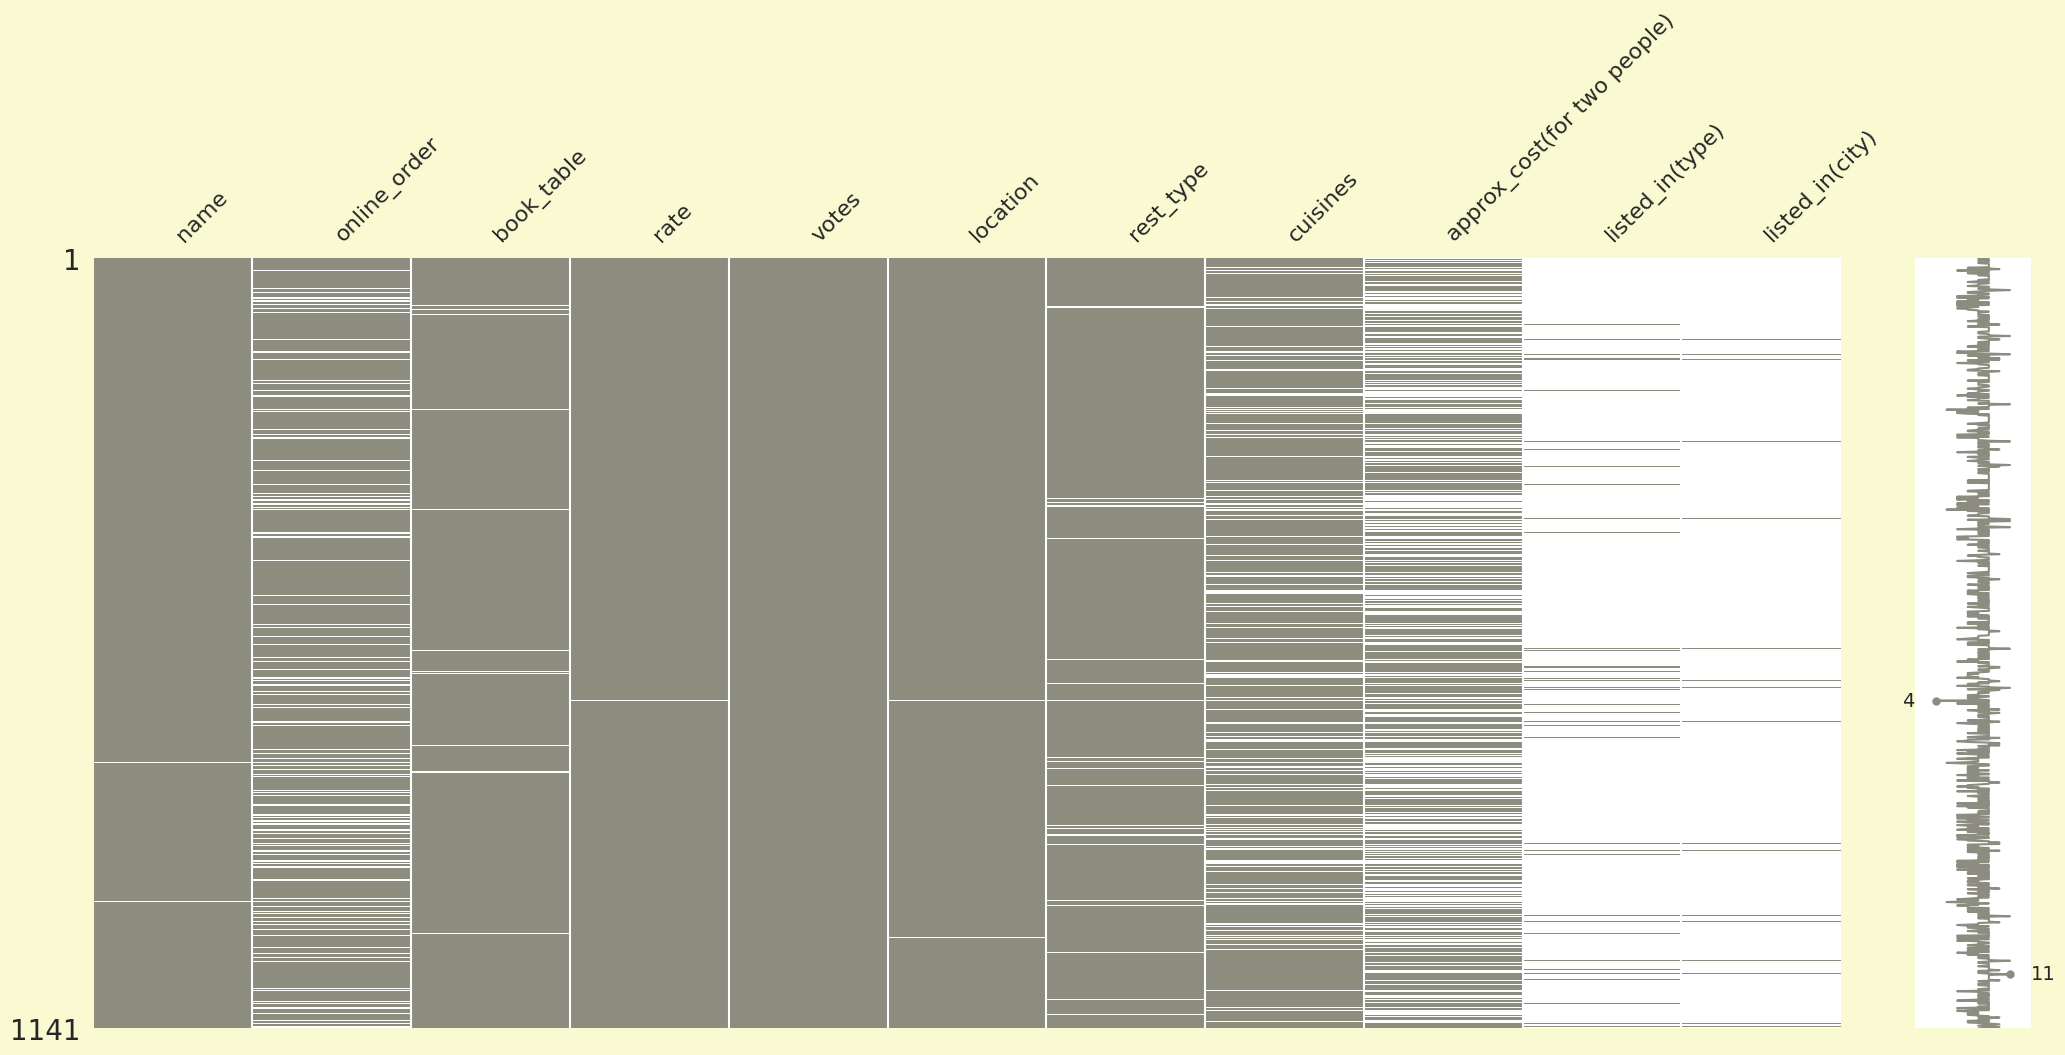

In [ ]:
# Import missingno for missing data visualization
import missingno as msno
# Visualize missing values in the dataset
msno.matrix(df,color=(0.55, 0.55, 0.5));

In [ ]:
# Drop rows with missing values
df.dropna(inplace=True)

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">Information About the data set</span>

In [ ]:
# --- Print Dataset Detail ---
print('\033[7m'+'.: Dataset Details :.')
print('\033[0m\033[43m*' * 47 +'\033[0m')
df.info(memory_usage = False)

.: Dataset Details :.
***********************************************
<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 47 to 1060
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         14 non-null     object
 1   online_order                 14 non-null     object
 2   book_table                   14 non-null     object
 3   rate                         14 non-null     object
 4   votes                        14 non-null     object
 5   location                     14 non-null     object
 6   rest_type                    14 non-null     object
 7   cuisines                     14 non-null     object
 8   approx_cost(for two people)  14 non-null     object
 9   listed_in(type)              14 non-null     object
 10  listed_in(city)              14 non-null     object
dtypes: object(11)

In [ ]:
# Calculate the percentage of restaurants offering online orders
(df.online_order.value_counts()/df.shape[0])*100

,count
online_order,
"""Biryani",14.285714
Biryani,14.285714
"""Pasta",14.285714
2nd Main,14.285714
"""Veggie Delight",7.142857
"""Egg Biryani",7.142857
"""Chilli Paneer Pizza",7.142857
Masala Dosa,7.142857
"""Mutton Biryani",7.142857


In [ ]:
# Display unique values in the 'rate' column
print(f"\033[031m\033[1m")
print(df['rate'].unique())


[' Thali' ' Chinese"' ' Salad"' ' Fish' ' North Indian' ' French Fries'
 '"Biryani' ' Opposite Axis Bank' ' Salads' '"Pizza']


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">Cleaning the Rating </span>

In [ ]:
# Function to clean the 'rate' column by handling missing values and converting ratings to float
def rate_clean(value):
    if(value=='NEW' or value=='-'):# Handle missing values
        return np.nan
    else:
        value = str(value).split('/')# Extract the rating number
        value = value[0]
        return float(value)# Return NaN if conversion fails

In [ ]:
def rate_clean(value):
    if(value=='NEW' or value=='-'):
        return np.nan
    else:
        try:  # Try to convert the value to float
            value = str(value).split('/')
            value = value[0]
            return float(value)
        except ValueError:  # Handle the exception if conversion fails
            return np.nan  # or any other suitable value


In [ ]:
# Drop rows with missing values after rating cleaning
df.dropna(inplace=True)

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">Giving appropriate names to the Features </span>

In [ ]:
# Rename columns for better readability
df.rename(columns = {'name':'Restaurant Name','online_order':'Online Order','book_table':'Book Table'}, inplace = True)
df.rename(columns = {'rate':'Ratings','votes':'Votes','location':'Location','rest_type':'Type Of Restaurant','cuisines':'Cuisines'}, inplace = True)
df.rename(columns = {'approx_cost(for two people)':'Cost For Two', 'listed_in(type)':'Catagory',"listed_in(city)" : "Listed in City"}, inplace = True)

In [ ]:
# Fix encoding issues in restaurant names
df['Restaurant Name'] = df['Restaurant Name'].str.replace('Ã', '')
df['Restaurant Name'] = df['Restaurant Name'].str.replace('©', '')
df['Restaurant Name'] = df['Restaurant Name'].str.replace('Â', '')
df['Restaurant Name'] = df['Restaurant Name'].str.replace('', '')
df['Restaurant Name'] = df['Restaurant Name'].str.replace('', '')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Unique Location List in Bangalore </span>

In [ ]:

print(f"\033[034m\033[1m")
print("Unique Location List :")
print(f"\033[031m\033[1m")
print(df['Location'].unique())


Unique Location List :

['North Indian' " 'RATED\\n  Castle Rock have a nice theme" '600'
 ' Chinese' '400' ' Manchurian"' ' Bangalore' ' Salad' '"[(\'Rated 4.0\'']


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Number of Restaurant Categories   </span>

In [ ]:
print(f"\033[034m\033[1m")
print(df["Catagory"].unique())
print(f"\033[035m\033[1m")
print("Categories Count :")
df["Catagory"].value_counts()


['Delivery' 'Desserts' 'Dine-out' '34']

Categories Count :


,count
Catagory,
Dine-out,6
Delivery,5
34,2
Desserts,1


In [ ]:
df.isnull().sum()

,0
Restaurant Name,0
Online Order,0
Book Table,0
Ratings,0
Votes,0
Location,0
Type Of Restaurant,0
Cuisines,0
Cost For Two,0
Catagory,0


In [ ]:
df.shape

(14, 11)

In [ ]:
df.dtypes

,0
Restaurant Name,object
Online Order,object
Book Table,object
Ratings,object
Votes,object
Location,object
Type Of Restaurant,object
Cuisines,object
Cost For Two,object
Catagory,object


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Converting Cost of Two to Cost per Head     </span>

In [ ]:
#Changing Cost per head from cost of 2
#Changing Cost per head from cost of 2
df['Cost For Two']=df['Cost For Two'].str.replace(',','')
# Remove any non-digit characters before conversion to float.
df['Cost For Two'] = df['Cost For Two'].str.extract('(\d+)').fillna(0).astype(float)  # Extract digits, fill NaNs with 0, then convert
df['Cost For Two']=df['Cost For Two'].apply(lambda x: x/2)
df.rename(columns = {'Cost For Two':'Cost Per Head'}, inplace = True)

In [ ]:
# Count the occurrences of each restaurant type and sort them in descending order
ty=df['Type Of Restaurant'].value_counts(ascending  = False)
# Calculate the mean of the counted values (average number of restaurants per type)
np.mean(ty)

np.float64(1.4)

In [ ]:
# Filter restaurant types that have fewer than 10 occurrences
typeLessThan10=ty[ty<10]
# Display the filtered restaurant types
typeLessThan10

,count
Type Of Restaurant,
600,2
its ambience is of cave and garden with bamboo sticks. Awesome place to take some cool pics.\nThe price is competitively cheap when compared to other restaurants. Total worth the price. The quality of food and quantity is also good. Best place to hangout with friends in private cave table.\nWe had ordered fish fingers,2
"Thin Crust Pizza""",2
JP Nagar,2
"""[('Rated 4.0'",1
Biryani,1
"""Italian",1
"""[('Rated 3.0'",1
"Andhra""",1


In [ ]:
# Function to clean the 'Type Of Restaurant' column
# If a restaurant type appears less than 10 times, categorize it as 'others'
def cleanTypeOfRestaurant(value):
    if(value in typeLessThan10):
        return 'others'# Group rare restaurant types under 'others'
    else:
        return value # Keep the original value if it appears frequently
# Apply the cleaning function to the 'Type Of Restaurant' column
df['Type Of Restaurant']=df['Type Of Restaurant'].apply(cleanTypeOfRestaurant)
# Display the updated value counts to see the effect of grouping
df['Type Of Restaurant'].value_counts()

,count
Type Of Restaurant,
others,14


In [ ]:
# Count the occurrences of each unique location and sort them in descending order
location = df['Location'].value_counts(ascending  = False)
# Filter locations that appear less than 10 times
location_lessthan10 = location[location<10]
# Function to clean the 'Location' column
# If a location appears less than 10 times, categorize it as 'others'
def cleanlocation(value):
    if(value in location_lessthan10):
        return 'others'# Group rare locations under 'others'
    else:
        return value # Keep the original location if it appears frequently
# Apply the cleaning function to the 'Location' column
df['Location'] = df['Location'].apply(cleanlocation)
# Display the updated value counts to see the effect of grouping
df['Location'].value_counts()

,count
Location,
others,14


In [ ]:
# Count the occurrences of each unique cuisine type and sort them in descending order
cuisines = df['Cuisines'].value_counts(ascending  = False)
# Identify cuisines that appear only once
cuisines_lessthan1 = cuisines[cuisines<1]# Corrected to filter cuisines appearing exactly once
# Function to clean the 'Cuisines' column
# If a cuisine appears only once, categorize it as 'others'
def cleancuisines(value):
    if(value in cuisines_lessthan1):
        return 'others'  # Group rare cuisines under 'others'
    else:
        return value# Keep the original cuisine if it appears more than once
# Apply the cleaning function to the 'Cuisines' column
df['Cuisines'] = df['Cuisines'].apply(cleancuisines)

# Display the updated value counts to see the effect of grouping
df['Cuisines'].value_counts()

,count
Cuisines,
'RATED\n Ididnt like much.\n\nNeed to improve in food,2
chicken drum sticks,2
"Italian""",2
Machali Port,2
('Rated 1.0',1
450,1
650,1
also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),1
"""[('Rated 3.0'",1


In [ ]:
# Count the number of unique values in the 'Category' column
print(df[['Catagory']].nunique())
# Display the unique values present in the 'Category' column
print(df['Catagory'].unique())

Catagory    4
dtype: int64
['Delivery' 'Desserts' 'Dine-out' '34']


In [ ]:
df.head(2)

,Restaurant Name,Online Order,Book Table,Ratings,Votes,Location,Type Of Restaurant,Cuisines,Cost Per Head,Catagory,Listed in City
47,Casual Dining,"""Biryani",Chicken Guntur,Thali,Buttermilk,others,others,'RATED\n Ididnt like much.\n\nNeed to improv...,0.0,Delivery,Banashankari
115,Casual Dining,Biryani,"""North Indian","Chinese""",700,others,others,chicken drum sticks,0.0,Delivery,Banashankari


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 10 Unique Restaurant Names by Numbers   </span>

In [ ]:
# Apply ANSI escape codes for colored output (red & bold text)
print(f"\033[031m\033[1m")
# Print the number of unique restaurant names
print("Unique Restaurant Names :", df['Restaurant Name'].nunique())
# Apply formatting directly using the 'format' method within the style
df['Restaurant Name'].value_counts().nlargest(10).to_frame().style.background_gradient(cmap='copper').format("{:.2f}")


Unique Restaurant Names : 4


,count
Restaurant Name,
Casual Dining,8.00
Quick Bites,2.00
First Floor,2.00
Food Court,2.00


<font color="Brown" size=+1.5><b>*List of top 10 Restaurant Name in Bangalore is shown.*</b></font>

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 10 Unique Types Of Restaurant by Numbers </span>

In [ ]:
print(f"\033[031m\033[1m")
print("Unique Type Of Restaurant :", df['Type Of Restaurant'].nunique())
# Apply formatting using the 'format' method within the style
(df['Type Of Restaurant'].value_counts().nlargest(10).to_frame()
 .style.background_gradient(cmap='copper').format("{:.2f}"))


Unique Type Of Restaurant : 1


,count
Type Of Restaurant,
others,14.00


<font color="Brown" size=+1.5><b>*List of top 10 Type Of Restaurant in Bangalore is shown. Quick Bites has the highest number in Bangalore*</b></font>

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Different Catagory  </span>

In [ ]:
# Apply ANSI escape codes for colored output (red & bold text)
print(f"\033[031m\033[1m")
# Print the number of unique categories
print("Unique Catagory :", df['Catagory'].nunique())
# Apply formatting using the 'format' method within the style
(df['Catagory'].value_counts().nlargest(10).to_frame().style.background_gradient(cmap='copper').format("{:.2f}"))  # Use format to set precision


Unique Catagory : 4


,count
Catagory,
Dine-out,6.00
Delivery,5.00
34,2.00
Desserts,1.00


<font color="Brown" size=+1.5><b>*List of top 7 Catagory in Bangalore is shown. Delivery has the highest number in Bangalore*</b></font>

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 10 Unique Cuisines by Numbers </span>

In [ ]:
print(f"\033[031m\033[1m")
print("Unique Cuisines :", df['Cuisines'].nunique())
# Apply formatting using the 'format' method within the style
(df['Cuisines'].value_counts().nlargest(10).to_frame().style.background_gradient(cmap='copper').format("{:.2f}"))  # Use format to set precision


Unique Cuisines : 10


,count
Cuisines,
'RATED\n Ididnt like much.\n\nNeed to improve in food,2.00
chicken drum sticks,2.00
"Italian""",2.00
Machali Port,2.00
('Rated 1.0',1.00
450,1.00
650,1.00
also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),1.00
"""[('Rated 3.0'",1.00


<font color="Brown" size=+1.5><b>*List of top 10 Cuisines in Bangalore is shown. North Indian food is the most liked Cuisines in Bangalore*</b></font>

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> WordCloud for Cuisines</span>

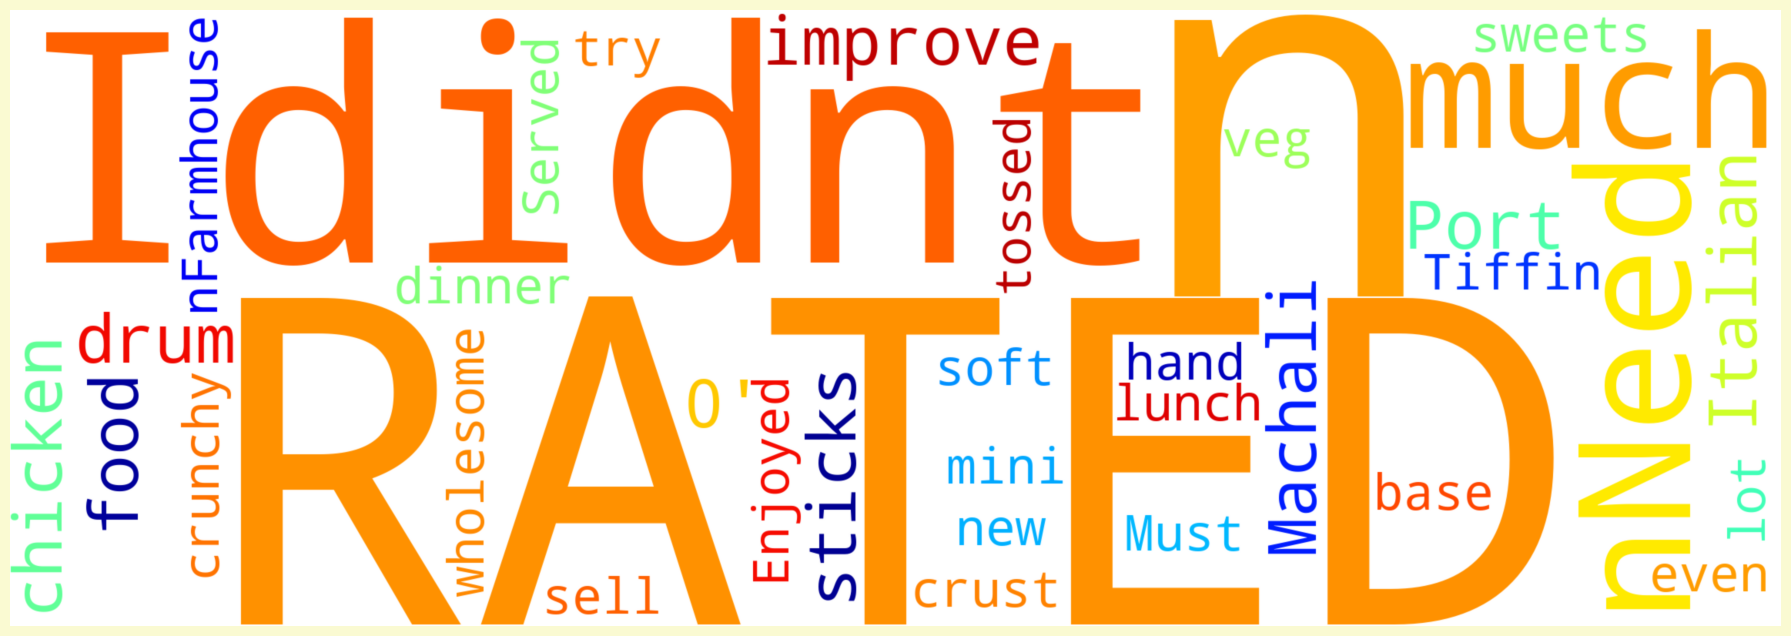

In [ ]:
from wordcloud import WordCloud, STOPWORDS

text = " ".join(Company for Company in df["Cuisines"])
#font = "Quicksand-Bold.ttf"
word_cloud = WordCloud(width = 2300,
                       height = 800,
                       colormap = 'jet',
                       background_color = "white").generate(text)
plt.figure(figsize = (50, 8))
plt.imshow(word_cloud, interpolation = "gaussian")
plt.axis("off")
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> 3D Scatter Plot </span>

In [ ]:
# 3D Scatter Plot
import plotly.express as px
fig = px.scatter_3d(df, x='Catagory', z='Cost Per Head', y='Ratings', color='Online Order')
fig.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 10 Listed in City by Numbers </span>

In [ ]:
print(f"\033[031m\033[1m")
print("Unique Listed in City :", df['Listed in City'].nunique())
# Apply formatting directly using the 'format' method within the style
(df['Listed in City'].value_counts().nlargest(10).to_frame()
 .style.background_gradient(cmap='copper').format("{:.2f}"))  # Use format to set precision


Unique Listed in City : 3


,count
Listed in City,
Banashankari,9.00
Bannerghatta Road,3.00
"""+91 9113260882",2.00


<font color="Brown" size=+1.5><b>*List of top 10 Listed in City in Bangalore is shown*</b></font>

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Percentage of Restaurant Listed in City  </span>

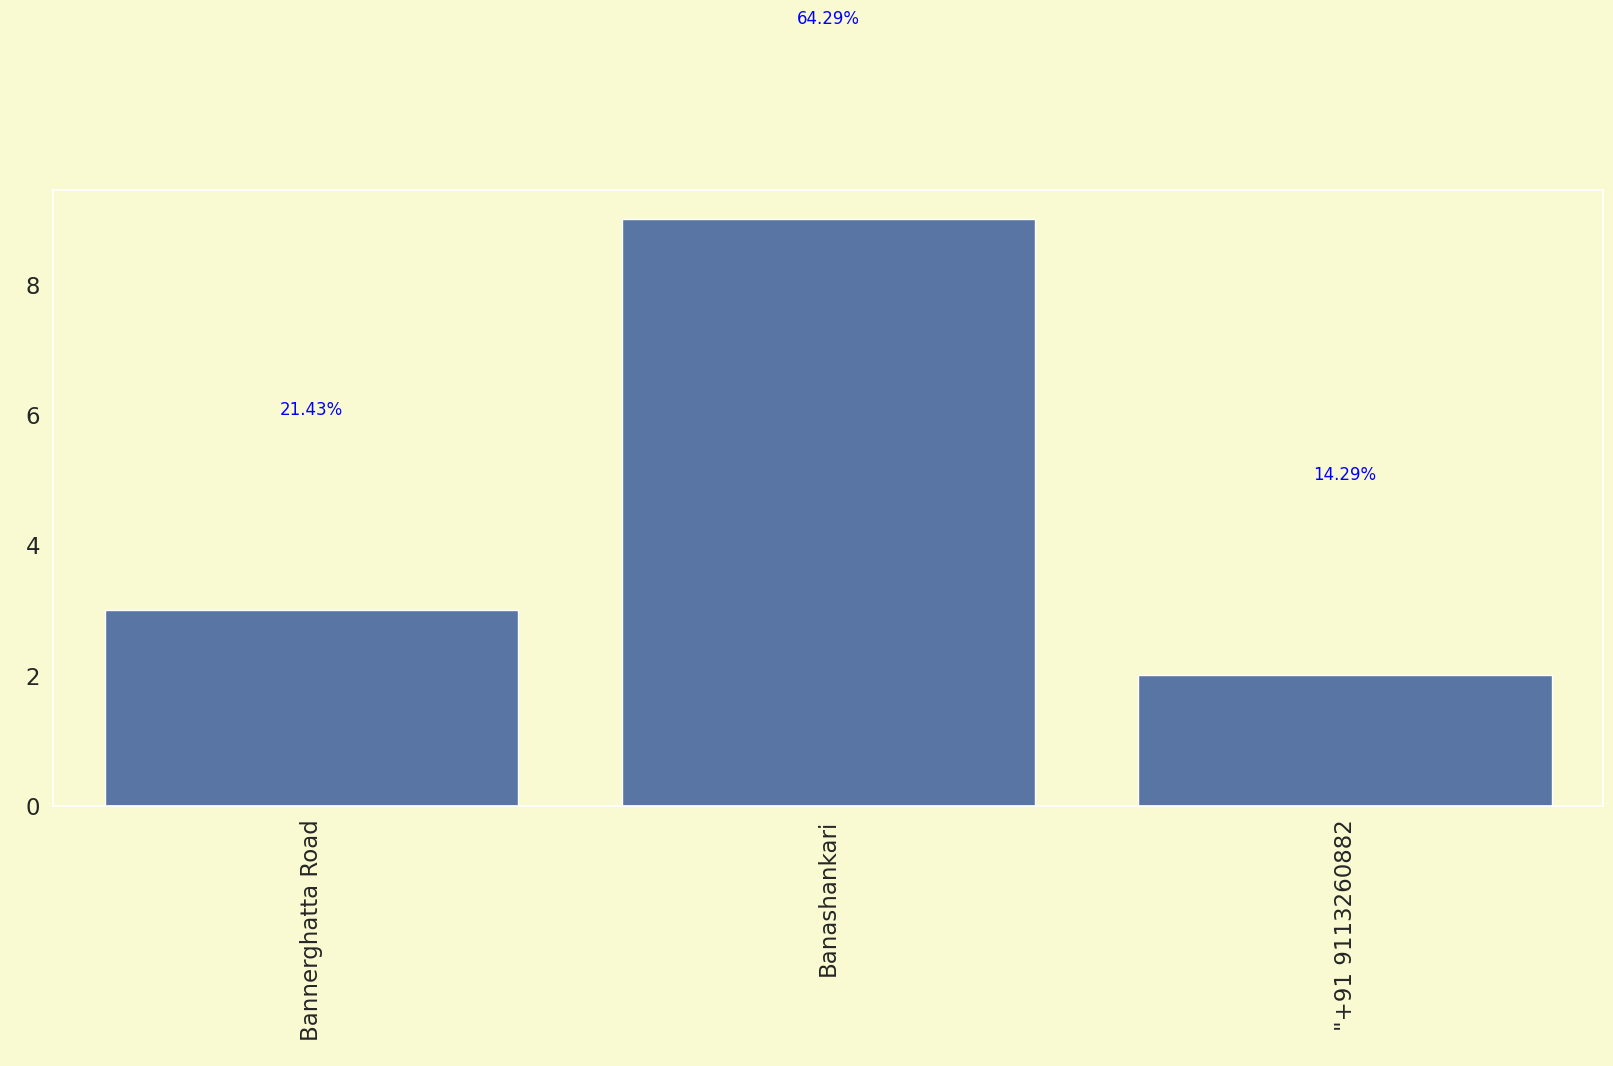

In [ ]:
plt.figure(figsize = (20, 8))
s = sns.countplot(x = df['Listed in City'].sort_values(ascending=False),data = df)
sizes=[]
for p in s.patches:
    height = p.get_height()
    sizes.append(height)
    s.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/len(df)*100),
            ha="center", fontsize=12,color = "blue")
    plt.xticks(rotation=90)

<font color="Brown" size=+1.5><b>*In this graph the percentage of restaurants in Bangalore is shown*</b></font>

<blockquote style="margin-right:auto; margin-left:auto; background-color: Yellow; padding: 1em; margin:2px;font-size:18px;font-family:Comic Sans Ms;color:Blue;letter-spacing:0.7px;text-align: justify;">
    

    
**Here the top 2 Location for the Maximum percentage Restaurant in Bangalore are:**
  
- BTM has highest percentage (6.27 %) of restaurants in Bangalore
- Karamangala 7th Block has second highest percentage (5.72 %) of restaurants in Bangalore
    
**Here the Top 2 Location for the Minimum percentage Restaurant in Bangalore are:**
    
- New BEL Road has least percentage (1.38 %) of restaurants in Bangalore
- Banashankari has second least percentage (1.76 %) of restaurants in Bangalore

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Book Table vs Cost Per Head  </span>

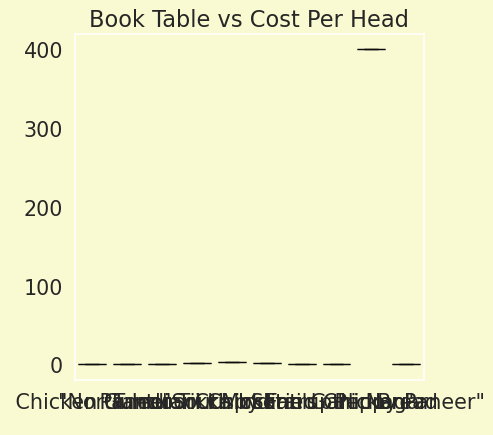

In [ ]:
plt.figure(figsize=(5,5),dpi=90)
plt.title('Book Table vs Cost Per Head')
sns.boxplot(x='Book Table',y='Cost Per Head',data=df,palette='copper');

<font color="Brown" size=+1.5><b>*Book Table vs Cost Per Head*</b></font>

<blockquote style="margin-right:auto; margin-left:auto; background-color: Yellow; padding: 1em; margin:2px;font-size:18px;font-family:Comic Sans Ms;color:Blue;letter-spacing:0.7px;text-align: justify;">
    
*The Restaurants which accepts booking have the highest Cost Per Head as compared to those which do not accept booking.*
  
*If Restaurants want increase  Cost Per Head sales they should start taking bookings.*

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Barplot for Category vs Cost per Head  </span>

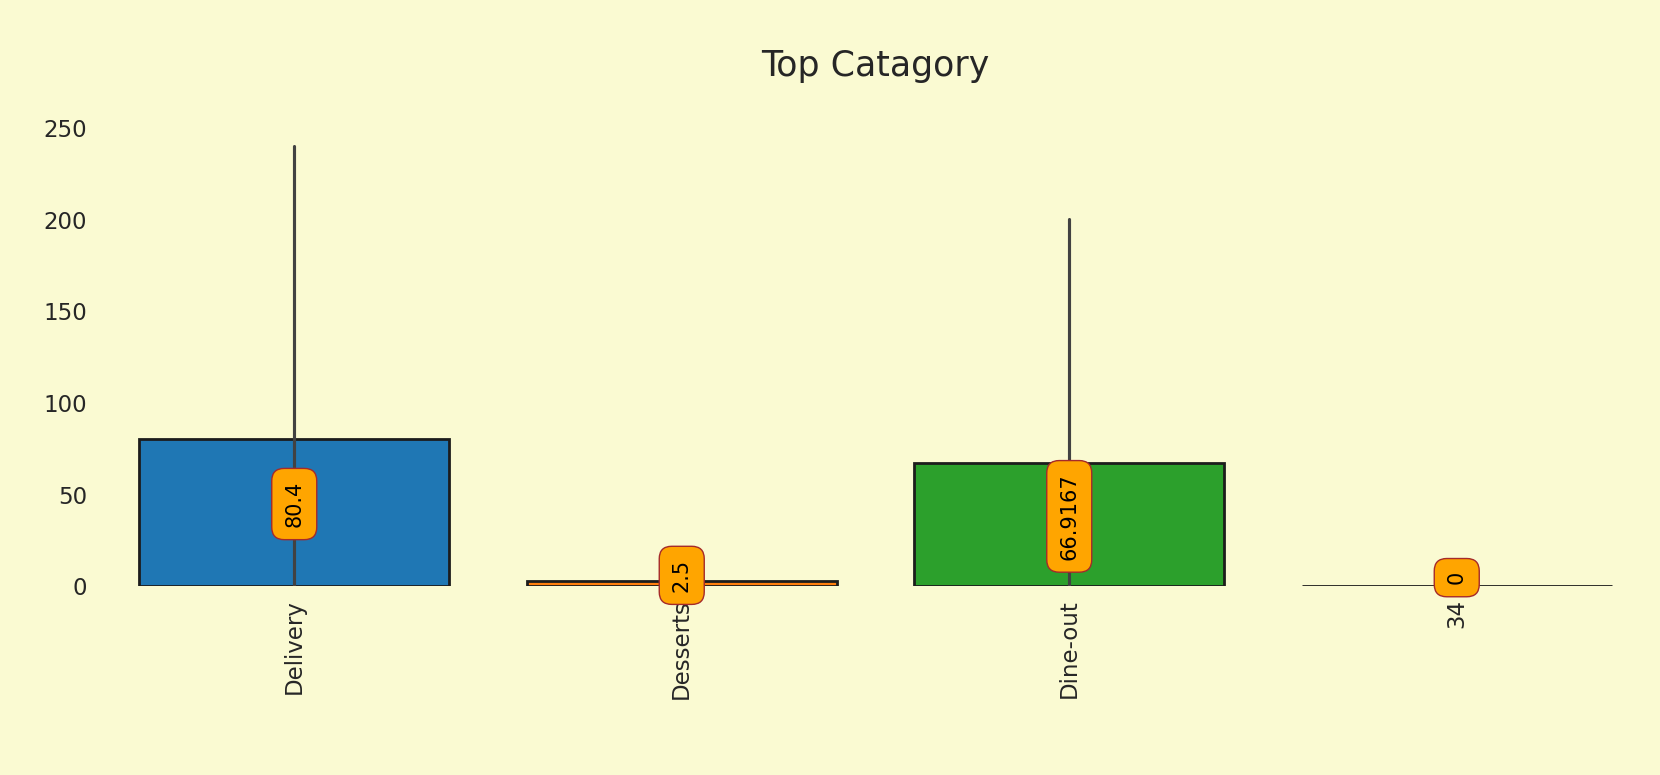

In [ ]:
plt.subplots(figsize=(20,6))
p = sns.barplot(x=df["Catagory"],y=df["Cost Per Head"],palette='tab10', saturation=1, edgecolor = "#1c1c1c", linewidth = 2)
p.axes.set_title("\nTop Catagory\n", fontsize=25)
plt.ylabel("Cost Per Head" , fontsize = 20)
plt.xlabel("\nCatagory" , fontsize = 20)
# plt.yscale("log")
plt.xticks(rotation = 90)
for container in p.containers:
    p.bar_label(container,label_type = "center",padding = 6,size = 15,color = "black",rotation = 90,
    bbox={"boxstyle": "round", "pad": 0.6, "facecolor": "orange", "edgecolor": "Brown", "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Barplot for Type Of Restaurant Vs Mean Cost Per Head </span>

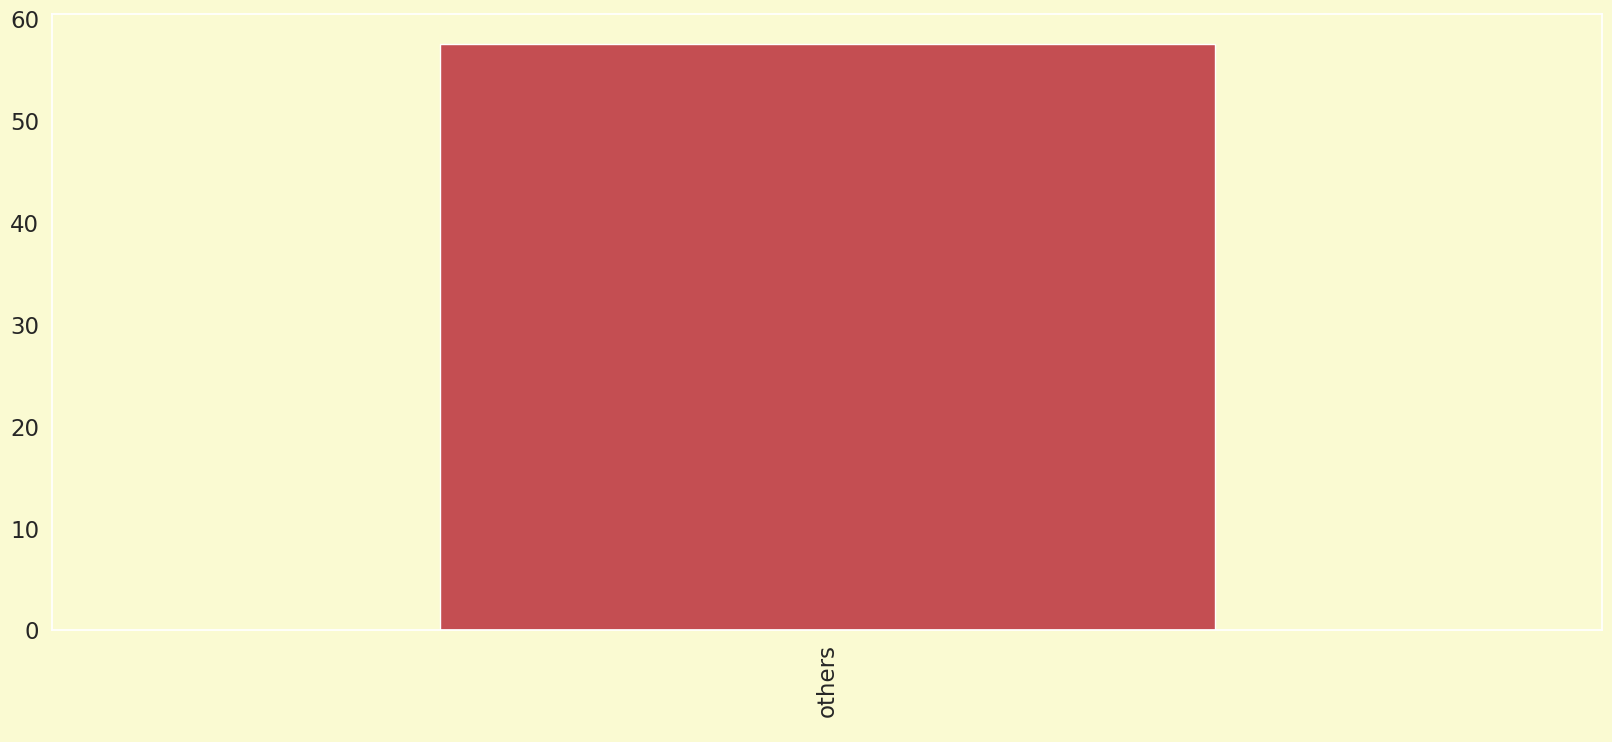

In [ ]:
plt.figure(figsize = (20,8))
df2=df.groupby('Type Of Restaurant')['Cost Per Head'].mean().sort_values(ascending=False)
color = [('r' if i < 500 else 'g') for i in df2]
df2.plot.bar(color=color);

In [ ]:
df[['Restaurant Name','Online Order','Book Table','Location','Type Of Restaurant','Cuisines','Catagory','Listed in City']].nunique()

,0
Restaurant Name,4
Online Order,10
Book Table,10
Location,1
Type Of Restaurant,1
Cuisines,10
Catagory,4
Listed in City,3


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Restaurant Category by total sum of (Ratings & Cost per Head) </span>

In [ ]:
import pandas as pd

# Convert 'Ratings' and 'Cost Per Head' to numeric, handling errors
df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce')
df['Cost Per Head'] = pd.to_numeric(df['Cost Per Head'], errors='coerce')

# Drop rows where both Ratings and Cost Per Head are NaN
df = df.dropna(subset=['Ratings', 'Cost Per Head'], how='all')

# Group by 'Category' and calculate the mean
result = df.groupby('Catagory')[['Ratings', 'Cost Per Head']].mean()

# Apply styling and formatting (avoid deprecated set_precision)
styled_result = result.style.background_gradient(cmap='copper').format("{:.2f}")

# Display the result
styled_result


,Ratings,Cost Per Head
Catagory,,
34,nan,0.00
Delivery,nan,80.40
Desserts,nan,2.50
Dine-out,nan,66.92


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Restaurant Category by Mean of (Ratings & Cost per Head) </span>

In [ ]:
# Convert 'Ratings' and 'Cost Per Head' to numeric before grouping
df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce')
df['Cost Per Head'] = pd.to_numeric(df['Cost Per Head'], errors='coerce')

# Group by 'Catagory' and calculate the mean, handling non-numeric values
result = df.groupby('Catagory')[['Ratings', 'Cost Per Head']].agg('mean')

# Apply styling and formatting
# Instead of set_precision, use format to control precision
styled_result = result.style.background_gradient(cmap='copper').format("{:.2f}")

# Display the result
styled_result

,Ratings,Cost Per Head
Catagory,,
34,nan,0.00
Delivery,nan,80.40
Desserts,nan,2.50
Dine-out,nan,66.92


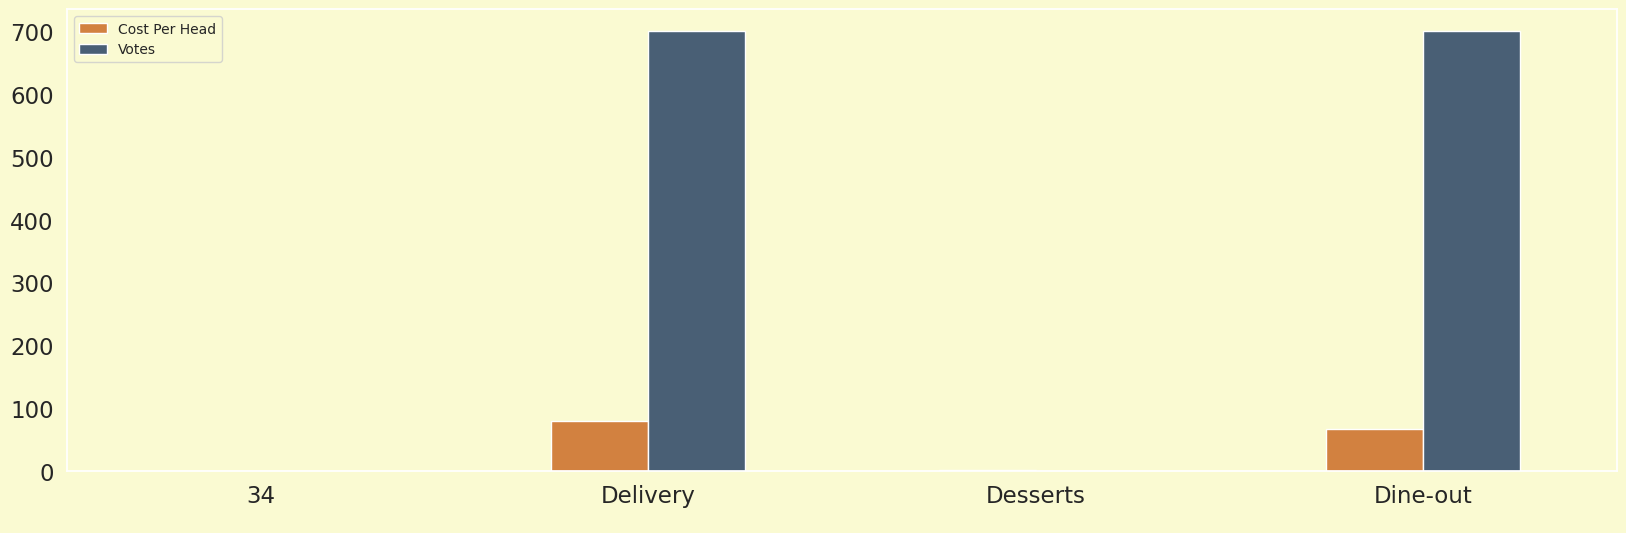

In [ ]:
color = ['#D28140','#495F75']
# Ensure 'Cost Per Head' and 'Votes' are numeric
df['Cost Per Head'] = pd.to_numeric(df['Cost Per Head'], errors='coerce')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Group by 'Catagory' and calculate the mean of numeric columns only
df.groupby(["Catagory"])[['Cost Per Head','Votes']].mean().plot(kind="bar",figsize=(20,6),color=color);
plt.xticks(rotation=0);

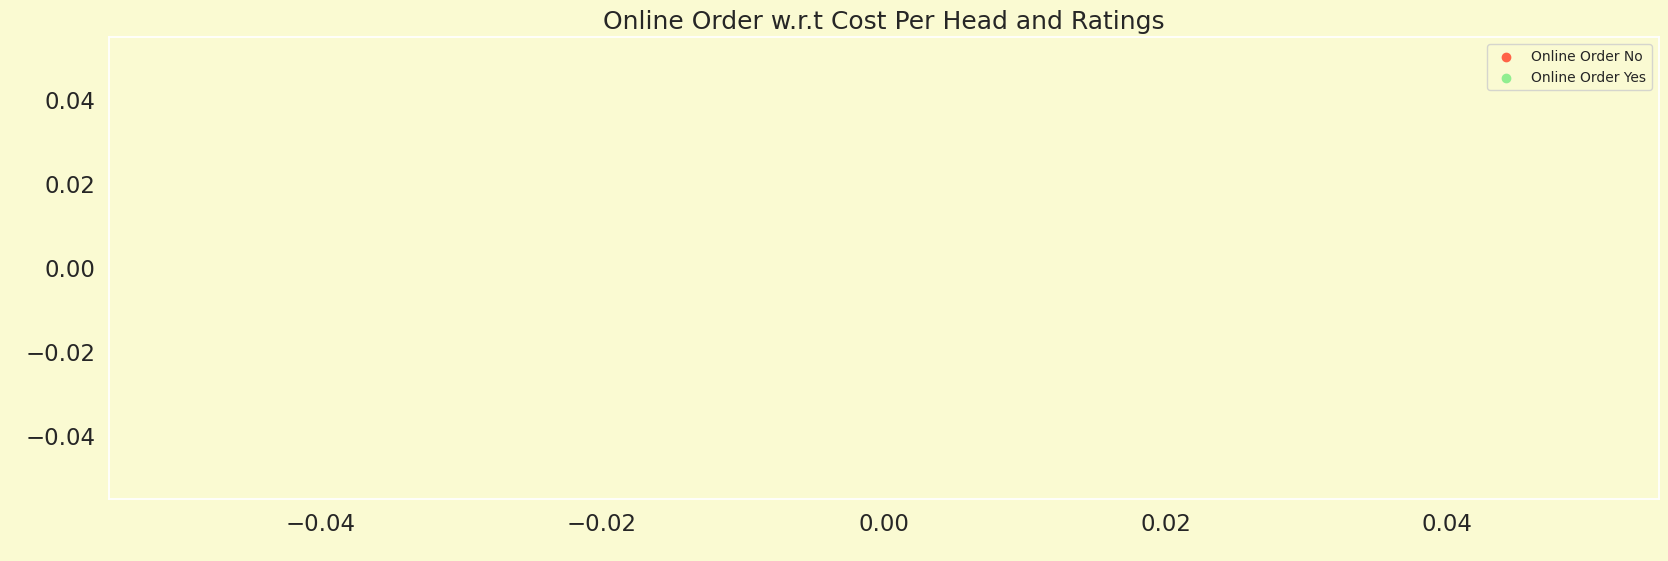

In [ ]:
import matplotlib.font_manager
plt.figure(figsize=(20,6))

plt.scatter(df['Cost Per Head'][df['Online Order']=="Yes"],
            df.Ratings[df['Online Order']=="Yes"],
            c="tomato")

plt.scatter(df['Cost Per Head'][df['Online Order']=="No"],
            df['Ratings'][df['Online Order']=="No"],
            c="lightgreen")

plt.title("Online Order w.r.t Cost Per Head and Ratings")
plt.xlabel("Cost Per Head")
plt.legend(["Online Order No", "Online Order Yes"])
plt.ylabel("Ratings");

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 10 Type Of Restaurant with Percentage </span>

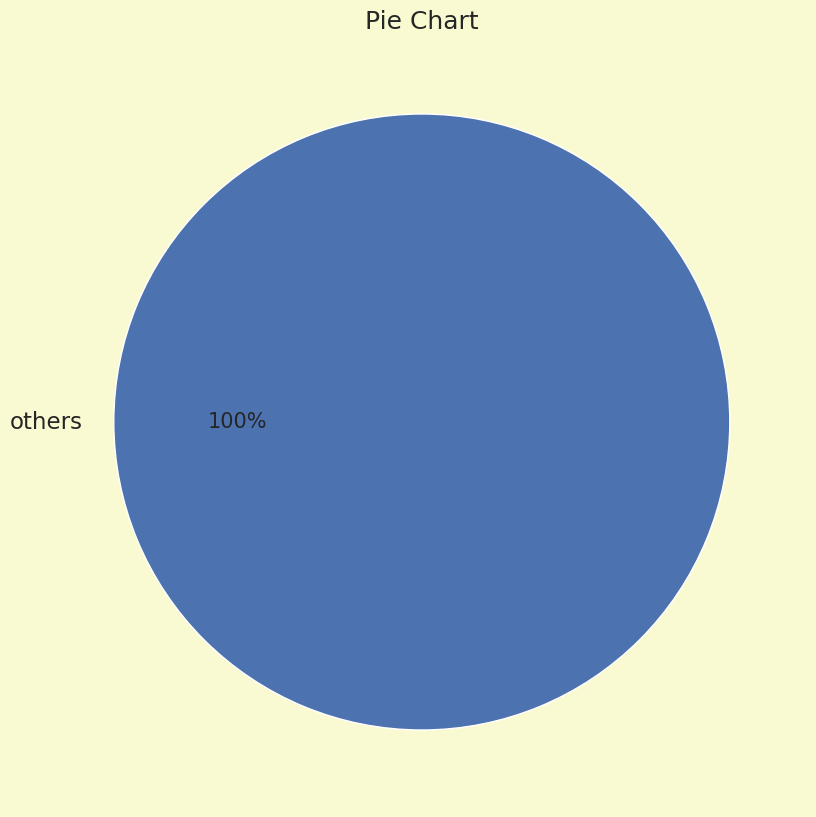

In [ ]:

df["Type Of Restaurant"].value_counts()[:10].plot.pie(figsize = (10, 10),
                                             autopct = '%1.0f%%')
plt.title("Pie Chart")
plt.xticks(rotation = 90)
plt.show()

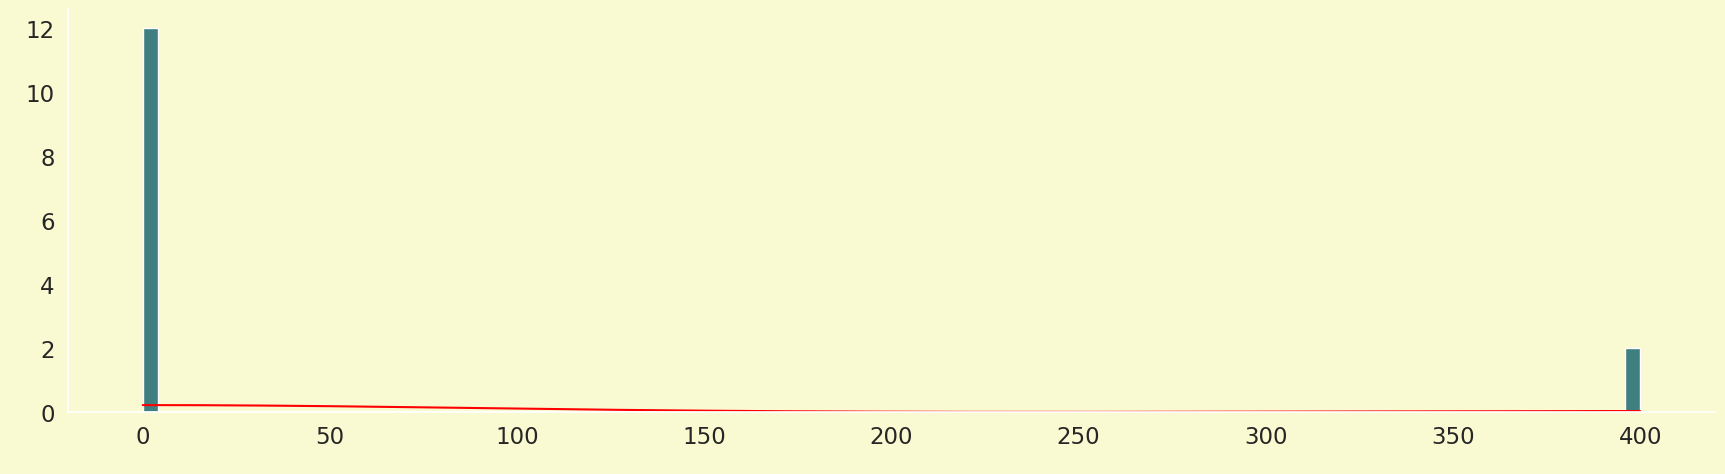

In [ ]:
sns.displot(data=df, x="Cost Per Head", kde=True, bins = 100,color = "red", facecolor = "#3F7F7F",height = 5, aspect = 3.5);

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Scatterplot Plot for Cost Per Head Vs Catagory  </span>

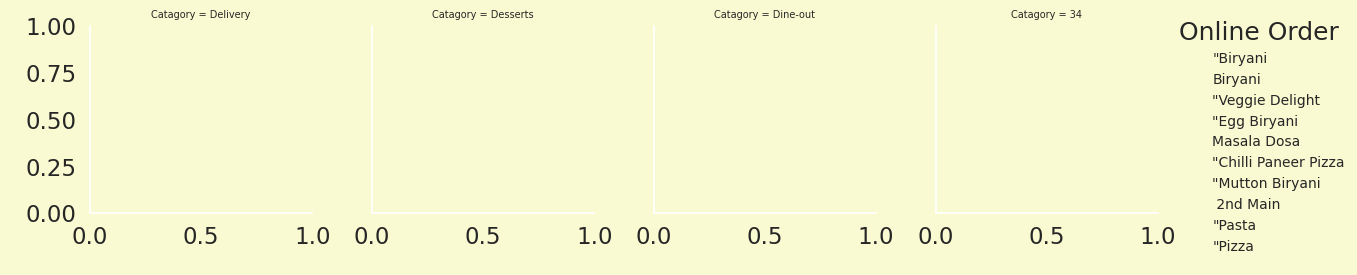

In [ ]:

g = sns.FacetGrid(df, col="Catagory", hue="Online Order")
g.map_dataframe(sns.scatterplot, x="Cost Per Head", y="Ratings")
g.add_legend()
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> HistPlot for Cost Per Head Vs Catagory  </span>

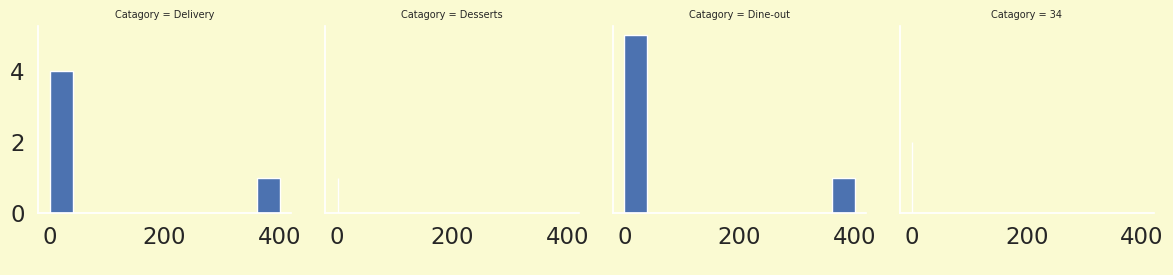

In [ ]:
g = sns.FacetGrid(df, col="Catagory")
g = g.map(plt.hist, "Cost Per Head")

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 50 Restaurant Chains in Bangalore by number of outlets </span>

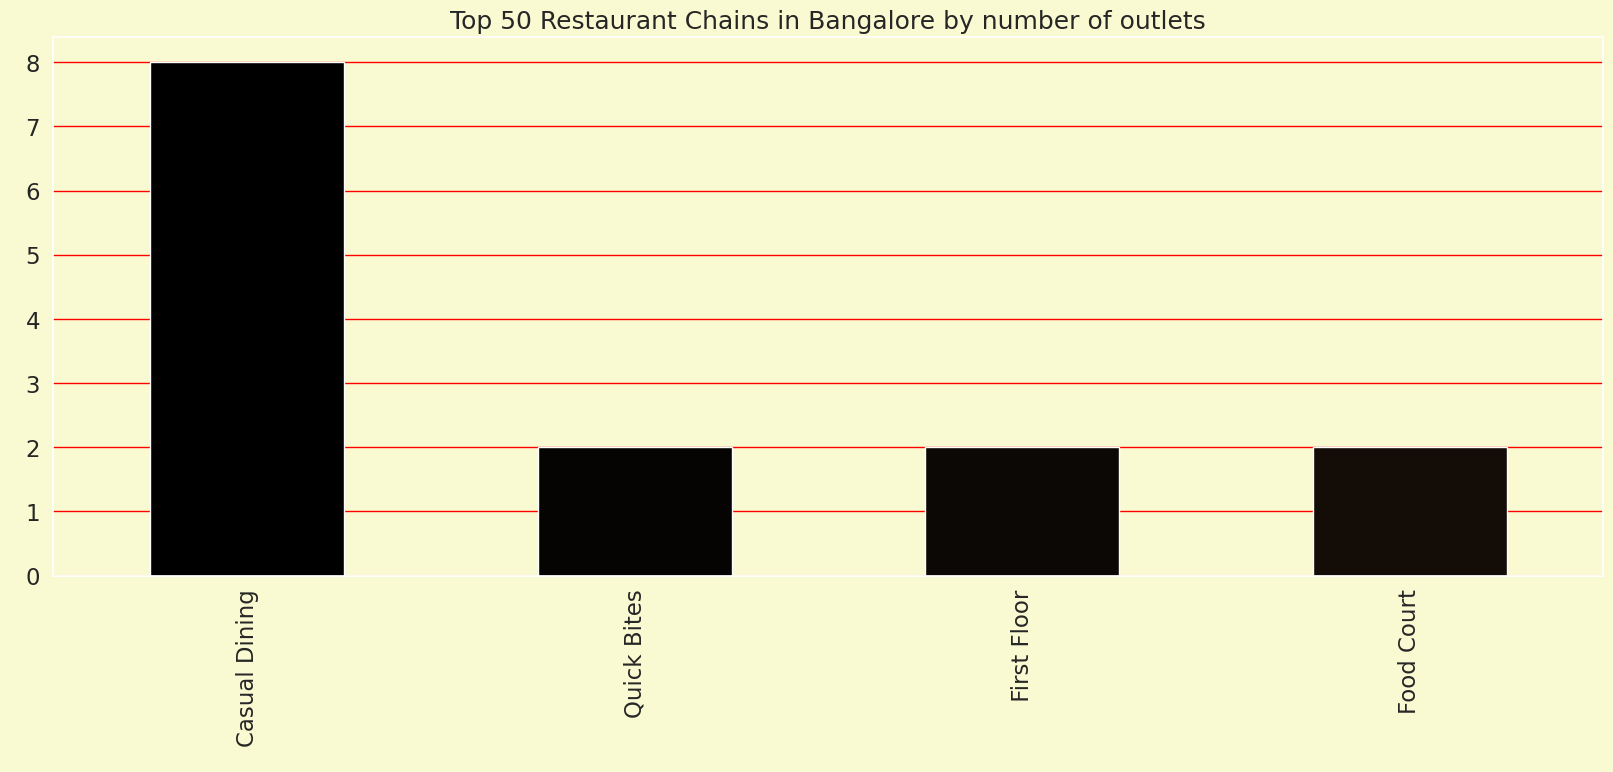

In [ ]:
plt.figure(figsize=(20,7))
df['Restaurant Name'].value_counts()[:50].plot(kind = 'bar', color = plt.cm.copper(np.linspace(0, 1, 50)))
plt.title('Top 50 Restaurant Chains in Bangalore by number of outlets')
plt.xlabel('Restaurant name')
plt.ylabel("No of Outlets")
plt.grid(axis = 'y')
plt.xticks(rotation = 90);

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Mean Cost Per Head spend by Customer in Location Listed in City </span>

In [ ]:
import pandas as pd

# Group by 'Listed in City' and compute mean 'Cost Per Head'
df_Listed = df.groupby(['Listed in City'])['Cost Per Head'].mean().reset_index()

# Ensure 'Cost Per Head' is numeric
df_Listed['Cost Per Head'] = pd.to_numeric(df_Listed['Cost Per Head'], errors='coerce')

# Sort values and apply styling correctly
styled_df = (
    df_Listed.sort_values(by='Cost Per Head', ascending=False)
    .style.background_gradient(cmap='copper')
    .format({'Cost Per Head': "{:.2f}"})  # Apply formatting only to the numeric column
)

# Display the styled DataFrame
styled_df


,Listed in City,Cost Per Head
2,Bannerghatta Road,266.67
1,Banashankari,0.67
0,"""+91 9113260882",0.00


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Maximum Cost Per Head spend by Customer in Location Listed in City </span>

In [ ]:
import pandas as pd

# Group by 'Listed in City' and find max 'Cost Per Head'
df_Listed = df.groupby(['Listed in City'])['Cost Per Head'].max().reset_index()

# Ensure 'Cost Per Head' is numeric
df_Listed['Cost Per Head'] = pd.to_numeric(df_Listed['Cost Per Head'], errors='coerce')

# Sort values and apply styling correctly
styled_df = (
    df_Listed.sort_values(by='Cost Per Head', ascending=False)
    .style.background_gradient(cmap='copper')
    .format({'Cost Per Head': "{:.2f}"})  # Correct replacement for set_precision
)

# Display the styled DataFrame
styled_df


,Listed in City,Cost Per Head
2,Bannerghatta Road,400.00
1,Banashankari,2.50
0,"""+91 9113260882",0.00


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> BarPlot of Location by Average Cost Per Head </span>

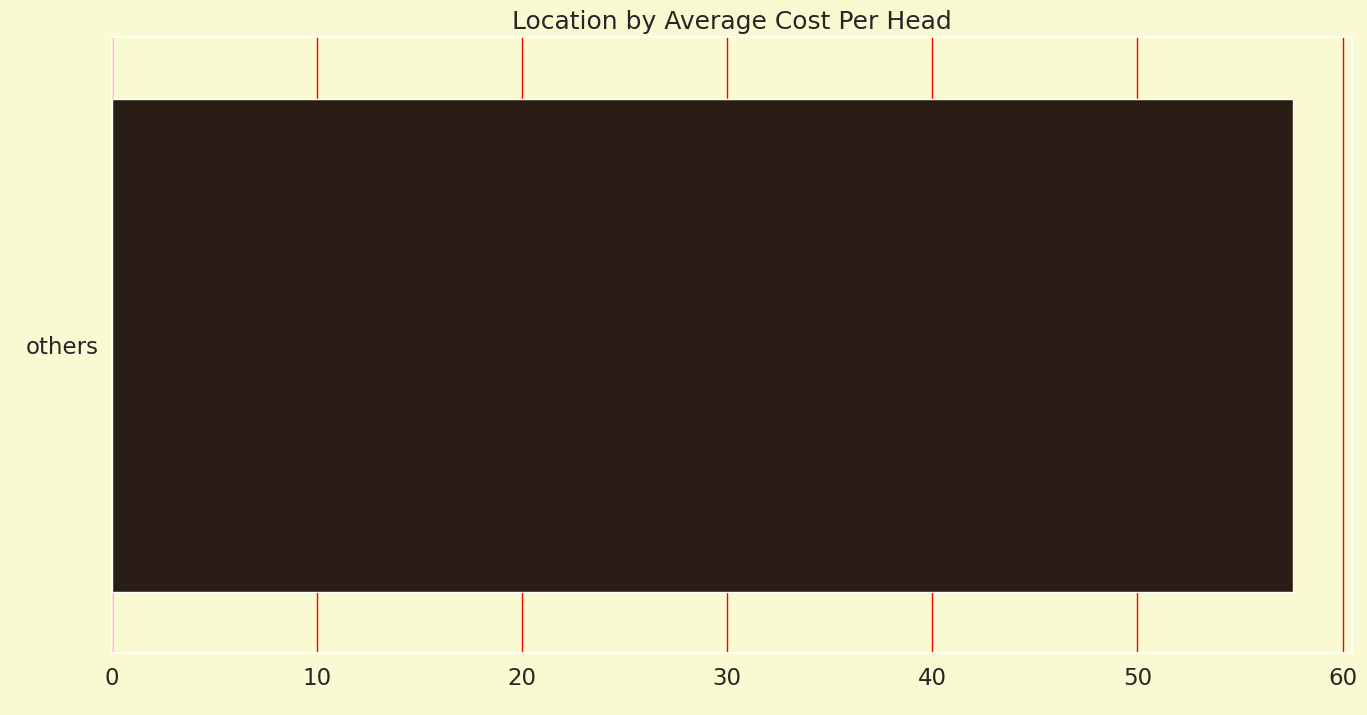

In [ ]:
colors=sns.color_palette('copper')[0:5]
res_chain = df['Cost Per Head'].groupby(df['Location'],sort=True)
dict_2={}
for i,j in df['Location'].value_counts()[:10].to_dict().items():
    dict_2[i]=round(res_chain.get_group(i).mean(),2)
cost_df2 = pd.DataFrame(list(dict_2.items()),columns=['Location',"Average Cost Per Head"])


fig , ax = plt.subplots(figsize=(16,8))
sns.barplot(data = cost_df2.sort_values(by=['Average Cost Per Head'],ascending=False),
            x = 'Average Cost Per Head',y = 'Location',palette=sns.blend_palette(colors, n_colors=10))
plt.title('Location by Average Cost Per Head')
plt.grid(axis = 'x')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> BarPlot of Restaurant Name (Lavelle Road) by Average Cost Per Head </span>

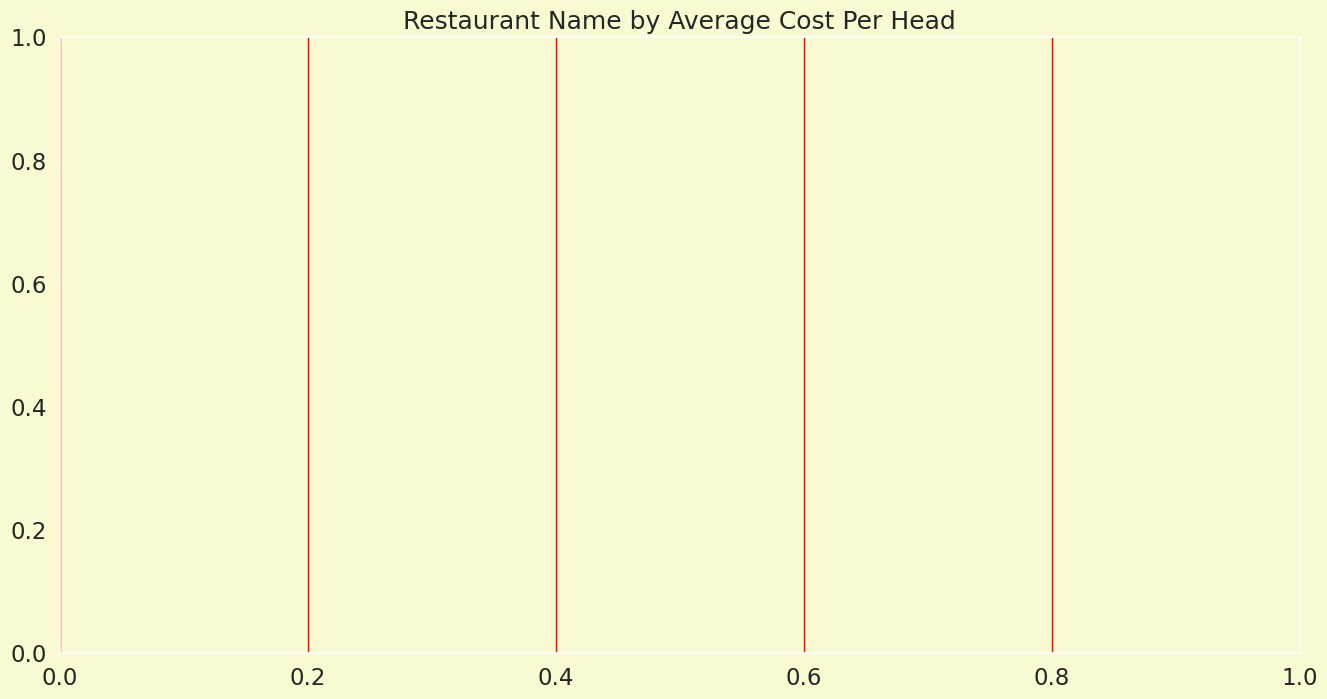

In [ ]:
Low_cost_perhead = df[df['Location'] == "Lavelle Road"]
colors=sns.color_palette('copper')[0:5]
res_chain = Low_cost_perhead['Cost Per Head'].groupby(Low_cost_perhead['Restaurant Name'],sort=True)
dict_2={}
for i,j in Low_cost_perhead['Restaurant Name'].value_counts()[:10].to_dict().items():
    dict_2[i]=round(res_chain.get_group(i).mean(),2)
cost_df2 = pd.DataFrame(list(dict_2.items()),columns=['Restaurant Name',"Average Rating"])


fig , ax = plt.subplots(figsize=(16,8))
sns.barplot(data = cost_df2.sort_values(by=['Average Rating'],ascending=False),
            x = 'Average Rating',y = 'Restaurant Name',palette=sns.blend_palette(colors, n_colors=10))
plt.title('Restaurant Name by Average Cost Per Head')
plt.grid(axis = 'x')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> WordCloud for Restaurant Name (Le Rock)  </span>

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Ensure case insensitivity by converting to lowercase
Le_Rock = df[df['Restaurant Name'].str.lower() == 'le rock']

# Check if there are any valid categories
if Le_Rock.empty:
    print("No data found for 'Le Rock'. Check the restaurant name spelling.")
else:
    # Ensure 'Catagory' column exists and has non-null values
    text = " ".join(str(cat) for cat in Le_Rock["Catagory"].dropna())

    if text.strip():  # Ensure the text is not empty
        # Generate WordCloud
        word_cloud = WordCloud(
            width=2300, height=800,
            colormap='jet',
            background_color="white",
            stopwords=STOPWORDS,
            max_words=100
        ).generate(text)

        # Display the WordCloud
        plt.figure(figsize=(15, 5))
        plt.imshow(word_cloud, interpolation="gaussian")
        plt.axis("off")  # Hide axis
        plt.show()
    else:
        print("No valid words found in 'Catagory' for 'Le Rock'.")


No data found for 'Le Rock'. Check the restaurant name spelling.


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> WordCloud for Restaurant Name (Le Rock) for Cuisines  </span>

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Check if Le_Rock DataFrame is empty
if Le_Rock.empty:
    print("No data found for 'Le Rock'. Check the restaurant name spelling.")
else:
    # Ensure 'Cuisines' column exists and has non-null values
    text = " ".join(str(cuisine) for cuisine in Le_Rock["Cuisines"].dropna())

    # Check if text is not empty after removing stop words
    if text.strip():
        word_cloud = WordCloud(width=2300,
                               height=800,
                               colormap='jet',
                               background_color="white").generate(text)
        plt.figure(figsize=(50, 8))
        plt.imshow(word_cloud, interpolation="gaussian")
        plt.axis("off")
        plt.show()
    else:
        print("No valid words found in 'Cuisines' for 'Le Rock'.")

No data found for 'Le Rock'. Check the restaurant name spelling.


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> WordCloud for Restaurant Name (Biergarten) for Cuisines  </span>

In [ ]:
Biergarten = df[df['Restaurant Name'] == 'Biergarten']
from wordcloud import WordCloud, STOPWORDS

# Check if Biergarten DataFrame is empty
if Biergarten.empty:
    print("No data found for 'Biergarten'. Check the restaurant name spelling.")
else:
    # Ensure 'Cuisines' column exists and has non-null values
    text = " ".join(str(cuisine) for cuisine in Biergarten["Cuisines"].dropna())

    # Check if text is not empty after removing stop words
    if text.strip():
        word_cloud = WordCloud(width=2300,
                               height=800,
                               colormap='jet',
                               background_color="white").generate(text)
        plt.figure(figsize=(50, 8))
        plt.imshow(word_cloud, interpolation="gaussian")
        plt.axis("off")
        plt.show()
    else:
        print("No valid words found in 'Cuisines' for 'Biergarten'.")

No data found for 'Biergarten'. Check the restaurant name spelling.


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top Restaurants by Average Cost Per Head  </span>

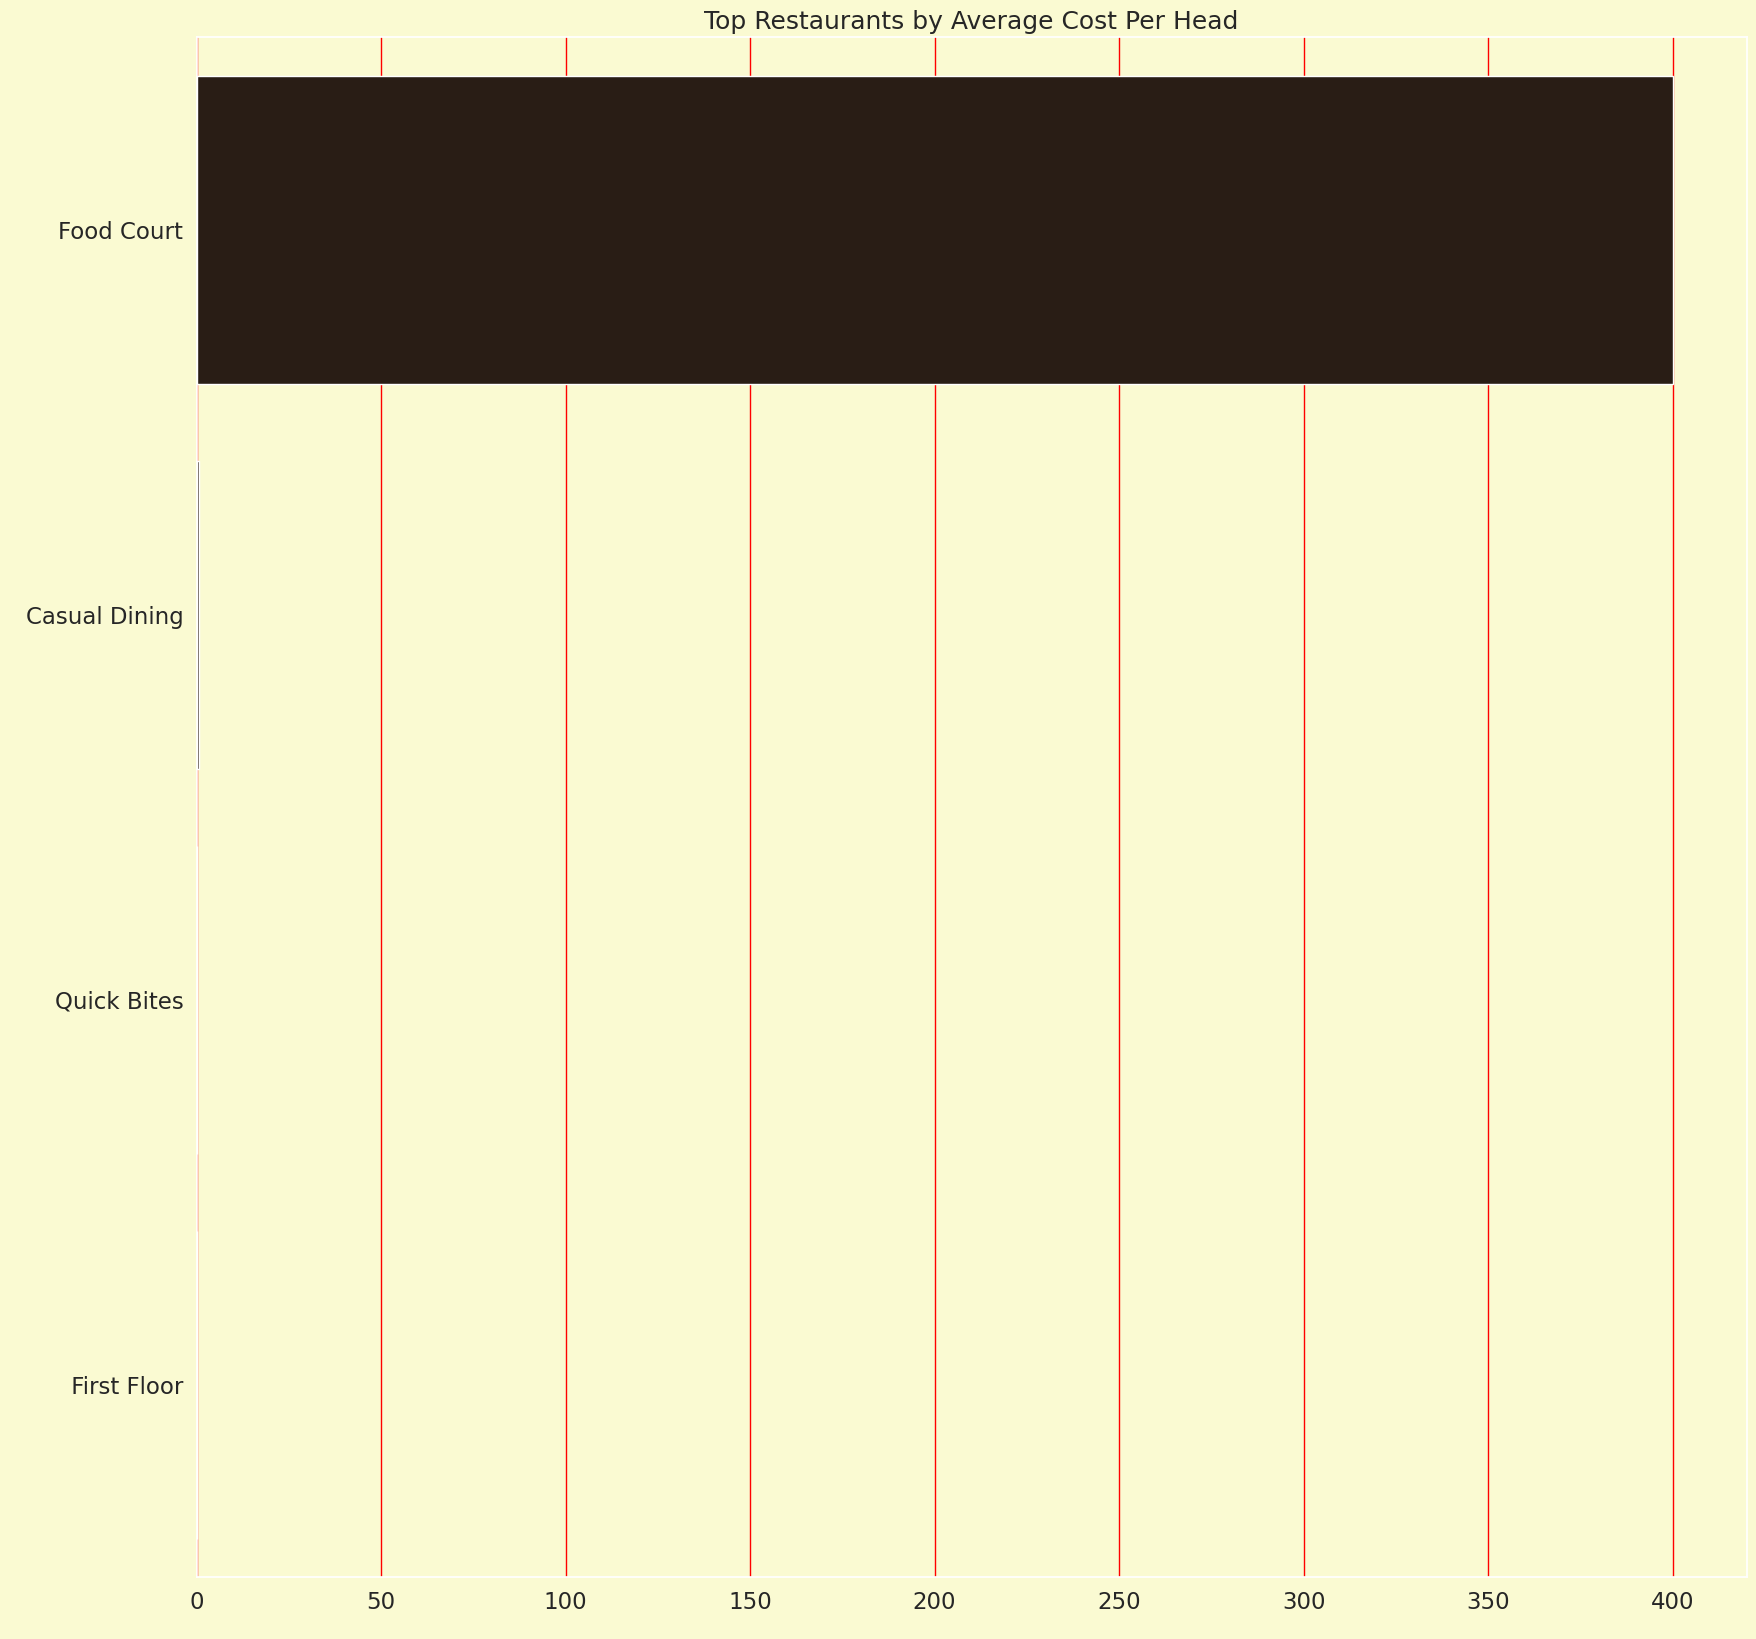

In [ ]:
colors=sns.color_palette('copper')[0:5]
res_chain = df['Cost Per Head'].groupby(df['Restaurant Name'],sort=True)
dict_2={}
for i,j in df['Restaurant Name'].value_counts()[:15].to_dict().items():
    dict_2[i]=round(res_chain.get_group(i).mean(),2)
cost_df2 = pd.DataFrame(list(dict_2.items()),columns=['Restaurant Name',"Average Cost Per Head"])


fig , ax = plt.subplots(figsize=(20,20))
sns.barplot(data = cost_df2.sort_values(by=['Average Cost Per Head'],ascending=False),
            x = 'Average Cost Per Head',y = 'Restaurant Name',palette=sns.blend_palette(colors, n_colors=15))
plt.title('Top Restaurants by Average Cost Per Head')
plt.grid(axis = 'x')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top Voted Restaurants in Bangalore  </span>

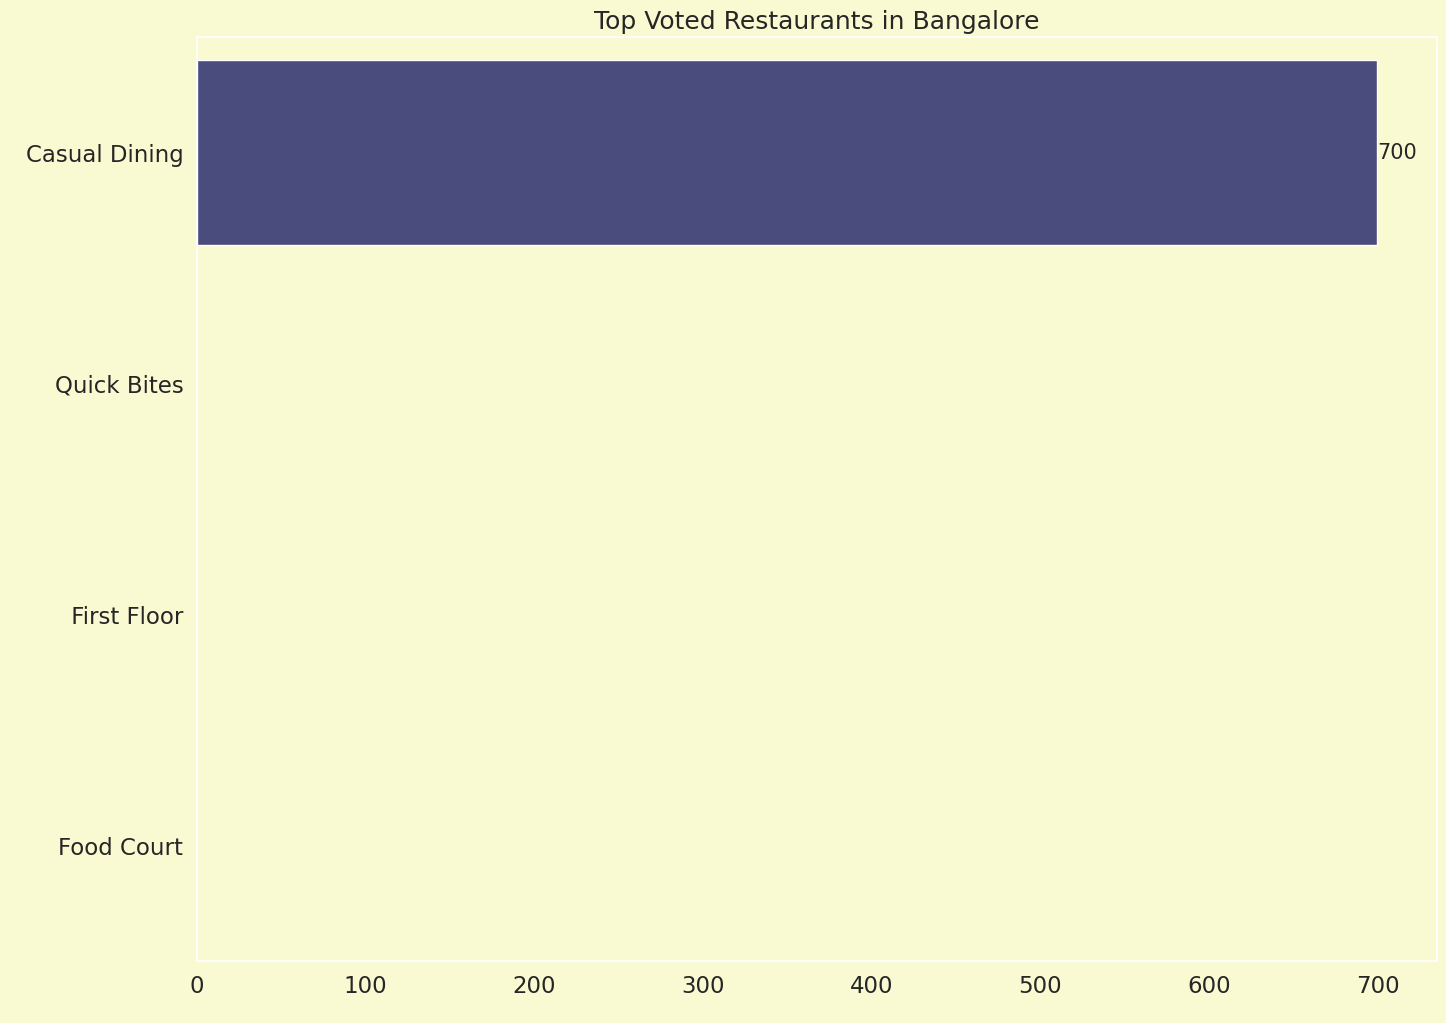

In [ ]:
vote_dataset = df.copy(deep=True)
vote_dataset = vote_dataset.sort_values(by=['Votes'], ascending=False)
vote_dataset = vote_dataset.drop_duplicates(subset=['Restaurant Name'], keep='first').reset_index()
vote_dataset = vote_dataset.head(20)

plt.figure(figsize=(16, 12))
vote_plt = sns.barplot(x='Votes', y='Restaurant Name', palette='viridis', data=vote_dataset)
vote_plt.bar_label(vote_plt.containers[0], label=vote_dataset['Votes'])
plt.title('Top Voted Restaurants in Bangalore')
plt.show()

In [ ]:
cuisine_dataset = df.copy(deep=True)
cuisine_dataset['Cuisines'] = cuisine_dataset['Cuisines'].apply(lambda x:x.split(','))
cuisine_dataset = cuisine_dataset.explode('Cuisines')
cuisine_dataset['Cuisines'] = cuisine_dataset['Cuisines'].apply(lambda x:x.replace(' ', ''))
cuisine_dataset = cuisine_dataset.groupby('Cuisines').aggregate({'Votes': list, 'Location': list})
cuisine_dataset['count'] = cuisine_dataset['Votes'].apply(lambda x:len(x))
cuisine_dataset['top_votes'] = cuisine_dataset['Votes'].apply(lambda x:max(x))
cuisine_dataset = cuisine_dataset.sort_values(by=['count', 'top_votes'], ascending=False).reset_index()
cuisine_dataset = cuisine_dataset.head(10)
cuisine_dataset

,Cuisines,Votes,Location,count,top_votes
0,chickendrumsticks,"[700.0, 700.0]","[others, others]",2,700.0
1,'RATED\nIdidntlikemuch.\n\nNeedtoimproveinfood,"[nan, nan]","[others, others]",2,NaN
2,"Italian""","[nan, nan]","[others, others]",2,NaN
3,MachaliPort,"[nan, nan]","[others, others]",2,NaN
4,"""[('Rated3.0'",[nan],[others],1,NaN
5,('Rated1.0',[nan],[others],1,NaN
6,450,[nan],[others],1,NaN
7,650,[nan],[others],1,NaN
8,alsolunchanddinner.Theyevensellsweets.Musttryi...,[nan],[others],1,NaN
9,softandcrunchyandwholesome.Enjoyedalot.\n\nFar...,[nan],[others],1,NaN


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Most popular cuisines in Bangalore  </span>

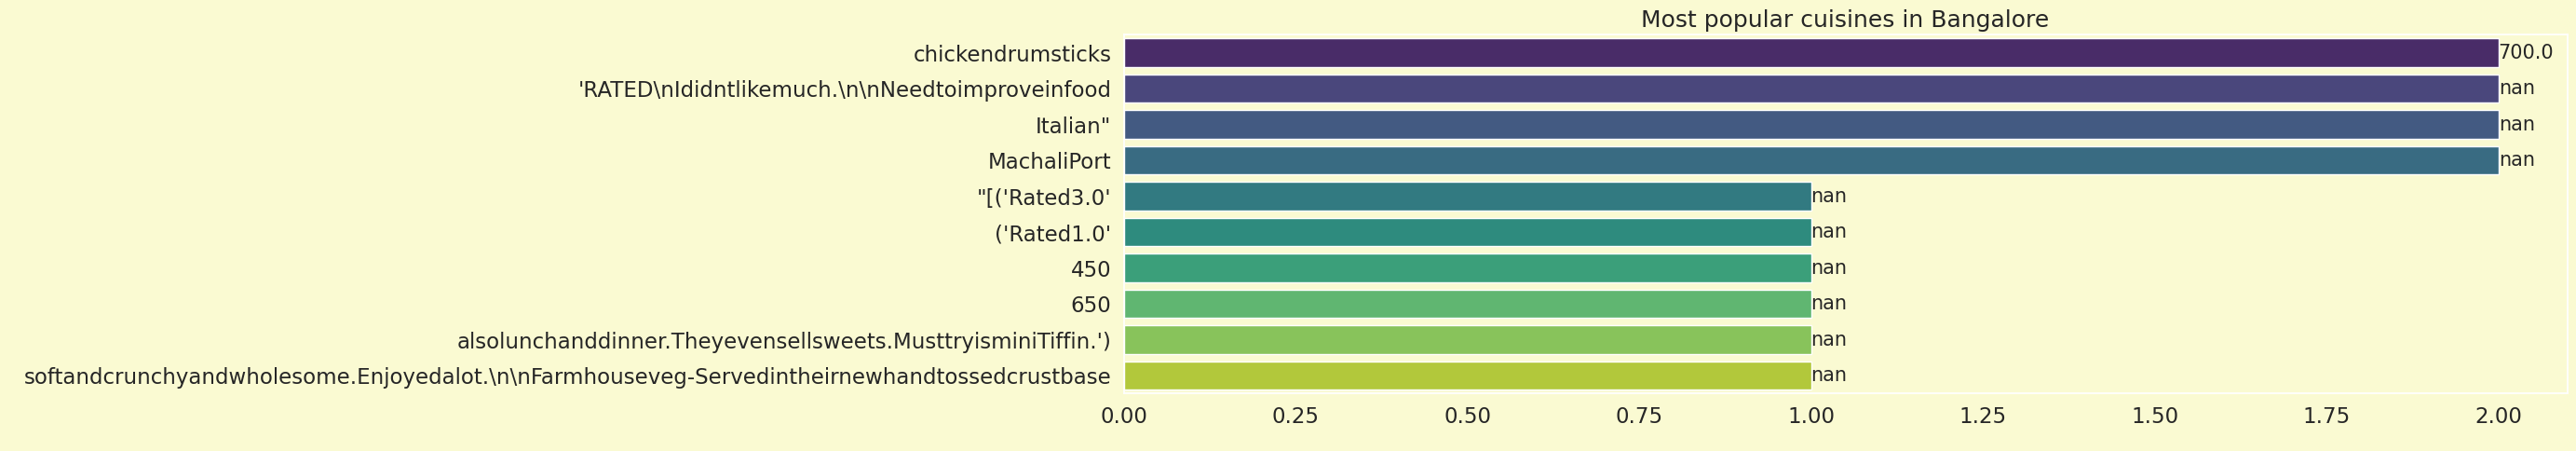

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 5))

# Create barplot
cuisine_plt = sns.barplot(x='count', y='Cuisines', data=cuisine_dataset, palette='viridis')

# Convert 'top_votes' column to strings for labeling
labels = cuisine_dataset['top_votes'].astype(str)

# Correct way to apply labels
for container, label in zip(cuisine_plt.containers, labels):
    cuisine_plt.bar_label(container, labels=[label], label_type='edge')

# Set title and show plot
plt.title('Most popular cuisines in Bangalore')
plt.show()


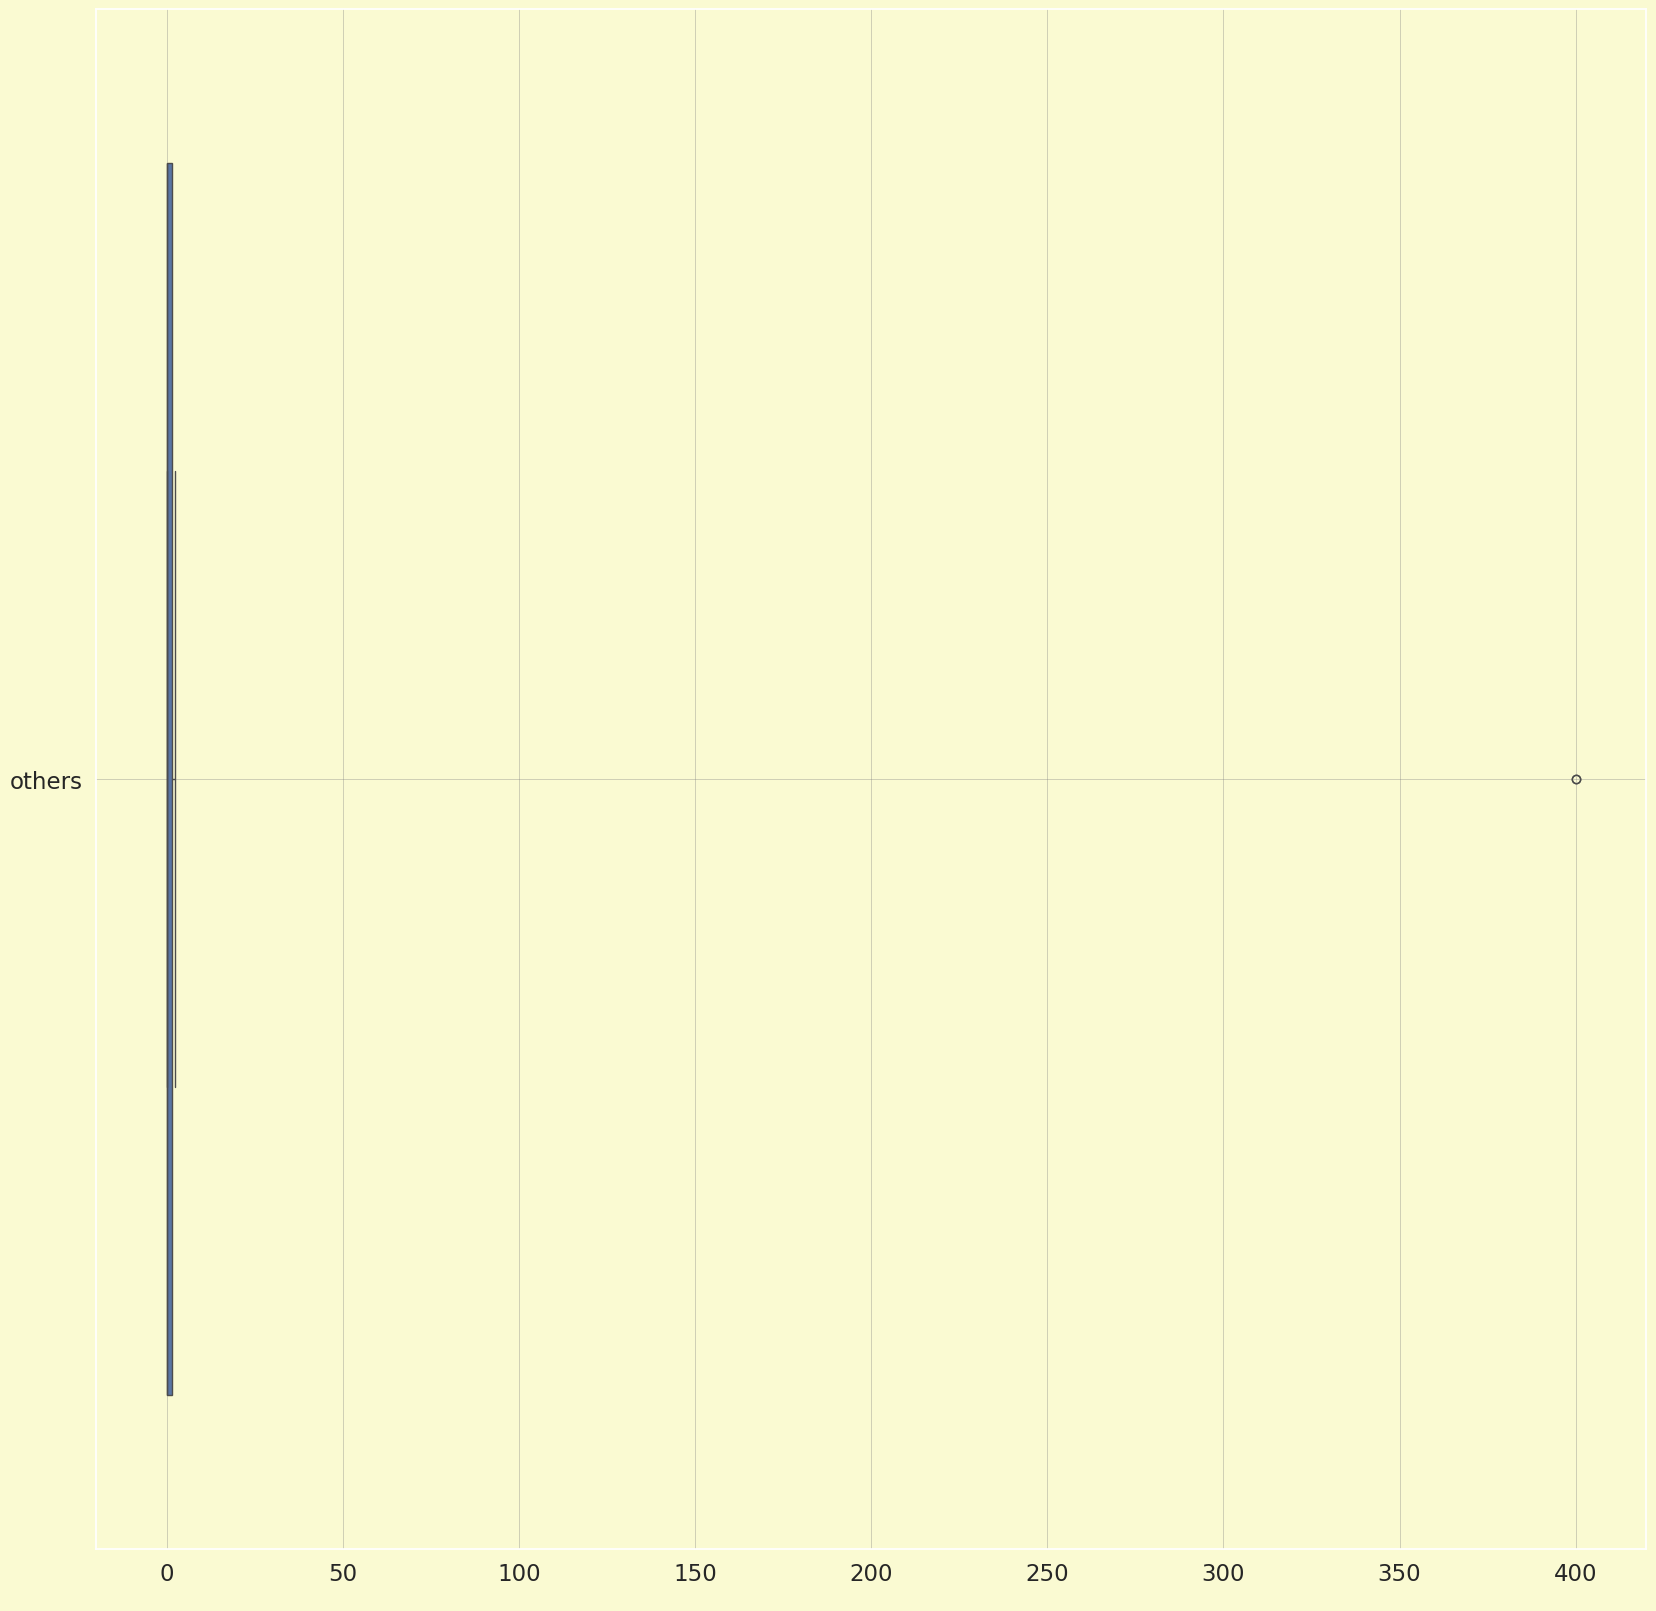

In [ ]:
fig = plt.figure(figsize=(20,20))
sns.boxplot(data=df, y="Location", x="Cost Per Head",color="#4C72B0")
plt.grid(True, color = "grey", linewidth = "0.5", alpha=0.5, axis="both")
plt.ylabel("")
plt.show()

In [ ]:
from IPython.core.display import HTML

def value_counts_all(df, columns):
    pd.set_option('display.max_rows', 50)
    table_list = []
    for col in columns:
        table_list.append(pd.DataFrame(df[col].value_counts()))
    return HTML(
        f"<table><tr> {''.join(['<td>' + table._repr_html_() + '</td>' for table in table_list])} </tr></table>")

value_counts_all(df, ["Location","Listed in City","Restaurant Name","Cuisines","Catagory"])

,count
Location,
others,14
,count
Listed in City,
Banashankari,9
Bannerghatta Road,3
"""+91 9113260882",2
,count
Restaurant Name,
Casual Dining,8


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">Top 15 Best Liked cuisines in Bangalore  </span>

In [ ]:
print('\033[7m'+'.: Cuisines :.')
print('\033[0m\033[43m*' * 47 +'\033[0m')
df['Cuisines'].value_counts()[0:15]

.: Cuisines :.
***********************************************


,count
Cuisines,
'RATED\n Ididnt like much.\n\nNeed to improve in food,2
chicken drum sticks,2
"Italian""",2
Machali Port,2
('Rated 1.0',1
450,1
650,1
also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),1
"""[('Rated 3.0'",1


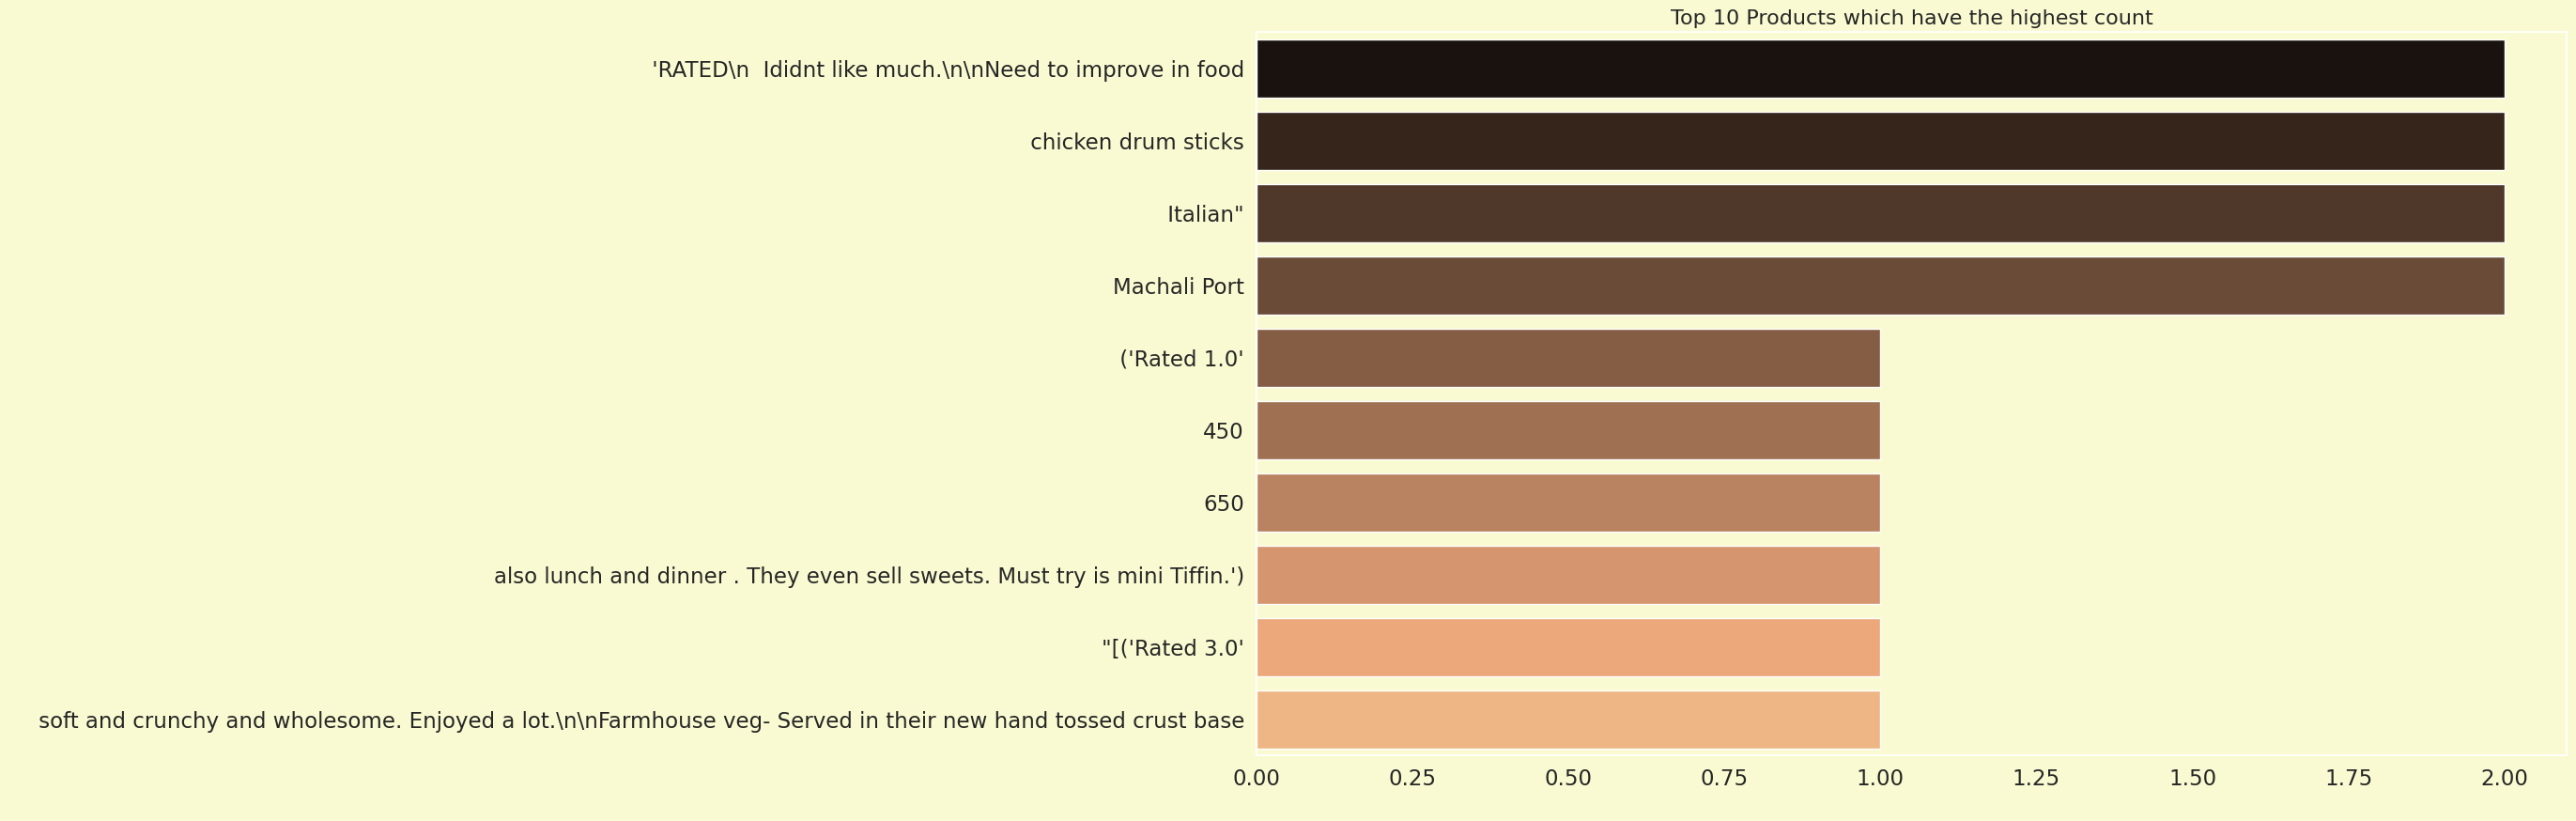

In [ ]:
# Top 15 Cuisines which have the highest Order

plt.figure(figsize=(18, 10))
sns.countplot(y='Cuisines', data=df, order=df['Cuisines'].value_counts().head(15).index, palette='copper')
plt.title('Top 10 Products which have the highest count', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> PieChat for Category of Food Bangalore  </span>

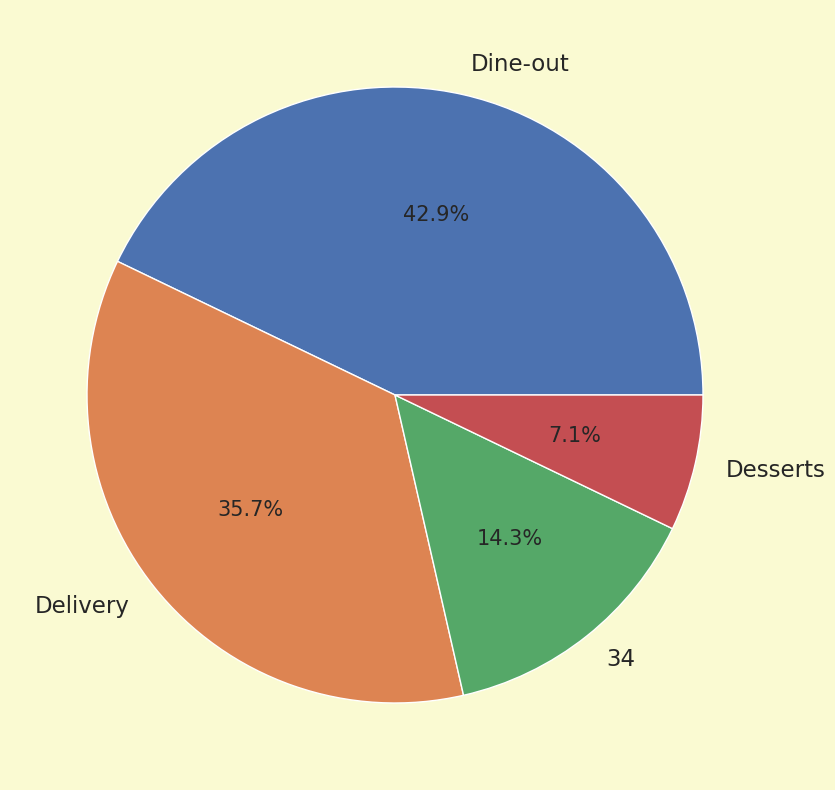

In [ ]:
plt.figure(figsize=(20,10))
plt.pie(df['Catagory'].value_counts(),labels=df["Catagory"].value_counts().keys(),autopct="%0.1f%%")
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 50 Location in Bangalore with total Collection (Cost per Head)  </span>

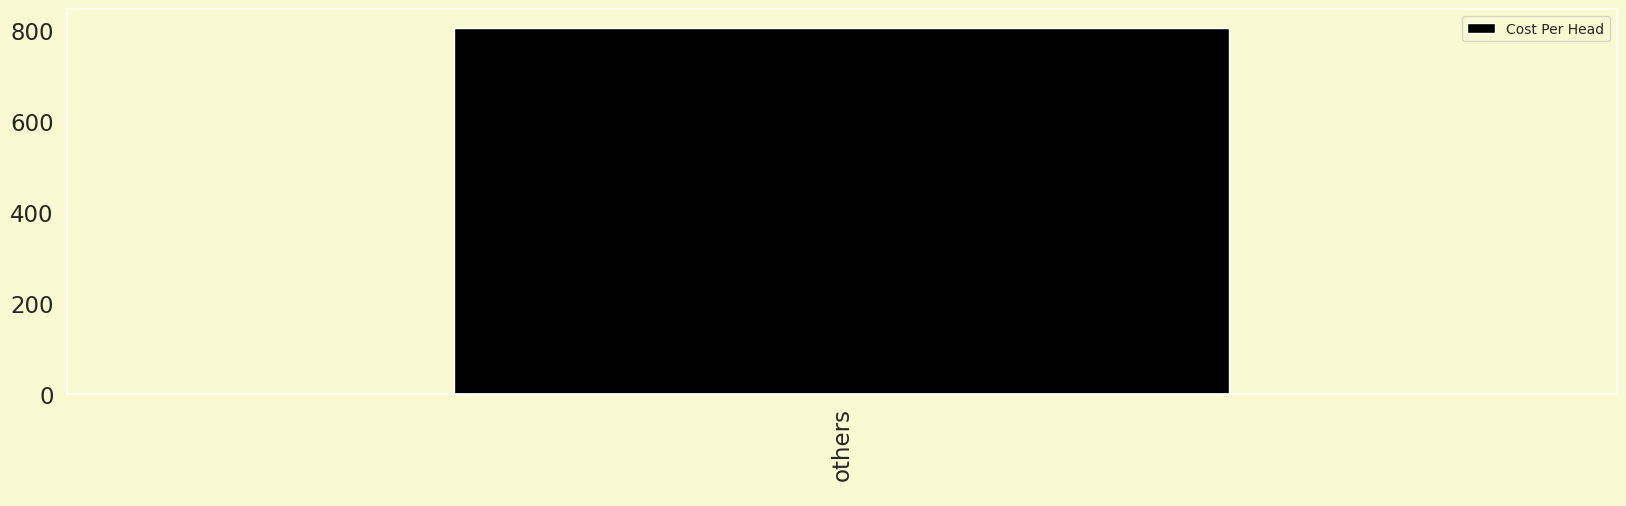

In [ ]:
df.groupby(['Location']).sum()[['Cost Per Head']].sort_values(by="Cost Per Head",ascending=False).nlargest(n=50, columns=['Cost Per Head']).plot.bar(color=plt.cm.copper(np.linspace(0, 1, 10)),figsize=(20,5))
plt.show();

In [ ]:
import pandas as pd

# Group by 'Location' and sum the 'Cost Per Head'
top_sp = df.groupby('Location', as_index=False)['Cost Per Head'].sum()

# Sort values in descending order and select top 10
top = top_sp.sort_values('Cost Per Head', ascending=False).head(10)

# Apply styling with background gradient and correct number formatting
top.style.background_gradient(cmap='copper').format({"Cost Per Head": "{:.2f}"})


,Location,Cost Per Head
0,others,806.00


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 50 Location in Bangalore with Average Cost per Head  </span>

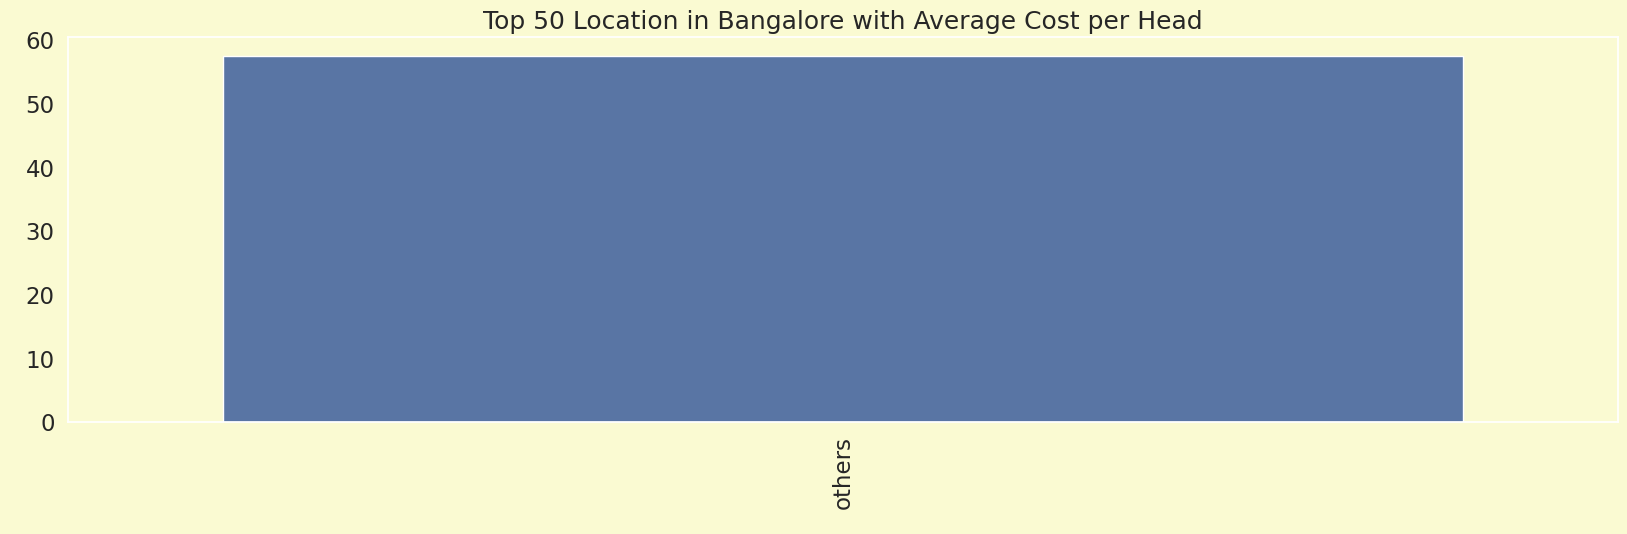

In [ ]:
# In which Location the Cost Per Head is highest
regions = df.groupby(['Location'])['Cost Per Head'].mean().sort_values(ascending=False)
regions = regions.reset_index()  # Reset index to include 'Location' as a column

fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='Location', y='Cost Per Head', data=regions)
plt.ylabel("Average Cost of Per) Head")
plt.title("Top 50 Location in Bangalore with Average Cost per Head")
plt.xticks(rotation=90)
plt.show()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from PIL import Image, ImageEnhance; Image.MAX_IMAGE_PIXELS = 5_000_000_000;
import plotly
import PIL

fig = px.scatter_3d(df, x='Cost Per Head', y='Ratings', z='Votes', color="Cost Per Head",
                    opacity=1, width=700, height=650,
                    color_continuous_scale='dense',
                    title="<b>Cost Per Head</b>")
fig.update_traces(marker_size=4)
fig.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Summary of Top 15 Cuisines in Bangalore </span>

In [ ]:
Summary_df = pd.DataFrame({'Cuisines':df['Cuisines'].value_counts().sort_index().index,
                        'Ratings':df.groupby(['Cuisines'])['Ratings'].mean().sort_index().values,
                        'Votes':df.groupby(['Cuisines'])['Votes'].mean().sort_index().values,
                        'Cost Per Head Mean': df.groupby(['Cuisines'])['Cost Per Head'].mean().sort_index().values,
                        'Cost Per Head Sum': df.groupby(['Cuisines'])['Cost Per Head'].sum().sort_index().values,
                         })
# Instead of set_precision, use format to control precision
(Summary_df.sort_values(by='Cost Per Head Mean', ascending=False)[:15]
 .style.background_gradient(cmap='copper')
 .format({"Ratings": "{:.2f}",
         "Votes": "{:.2f}",
         "Cost Per Head Mean": "{:.2f}",
         "Cost Per Head Sum": "{:.2f}"}))

,Cuisines,Ratings,Votes,Cost Per Head Mean,Cost Per Head Sum
2,"Italian""",nan,nan,400.00,800.00
9,also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),nan,nan,2.50,2.50
6,450,nan,nan,1.50,1.50
7,650,nan,nan,1.50,1.50
1,('Rated 1.0',nan,nan,0.50,0.50
0,'RATED\n Ididnt like much.\n\nNeed to improve in food,nan,nan,0.00,0.00
5,"""[('Rated 3.0'",nan,nan,0.00,0.00
4,soft and crunchy and wholesome. Enjoyed a lot.\n\nFarmhouse veg- Served in their new hand tossed crust base,nan,nan,0.00,0.00
3,chicken drum sticks,nan,700.00,0.00,0.00
8,Machali Port,nan,nan,0.00,0.00


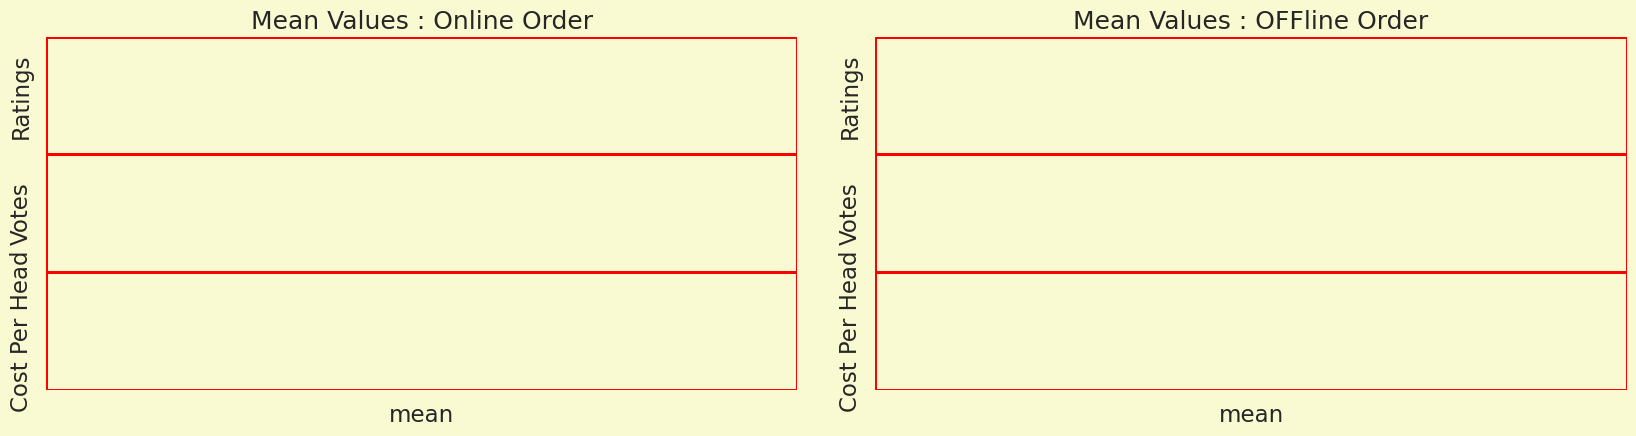

In [ ]:
yes = df[df['Online Order'] == 'Yes'].describe().T
no = df[df['Online Order'] == 'No'].describe().T

colors = ['#2BAE66','pink']

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (17,5))
plt.subplot(1,2,1)
sns.heatmap(yes[['mean']],annot = True,cmap = colors,linewidths = 0.8,linecolor = 'Red',cbar = False,fmt = '.2f')
plt.title('Mean Values : Online Order');

plt.subplot(1,2,2)
sns.heatmap(no[['mean']],annot = True,cmap = colors,linewidths = 0.8,linecolor = 'Red',cbar = False,fmt = '.2f')
plt.title('Mean Values : OFFline Order');

fig.tight_layout(pad = 2)

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Creating New Feature Cost Per Head Range  </span>

In [ ]:
# Cost Per Head Range
df['Cost_Per_Head_Range'] = pd.cut(df['Cost Per Head'],
bins=[0,50,250,500,1000,2000,3000],
labels=['Very Low','Low','Medium',"Average",'High',"Very High"])
# Instead of set_precision, use format to control precision within the style
(df['Cost_Per_Head_Range'].value_counts(ascending = False).to_frame()
 .style.background_gradient(cmap='copper')
 .format("{:.2f}"))  # Apply format to the desired column

,count
Cost_Per_Head_Range,
Very Low,4.00
Medium,2.00
Low,0.00
Average,0.00
High,0.00
Very High,0.00


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Creating New Feature Ratings_Grade  </span>

In [ ]:
def Grade(Ratings):
    if Ratings >= 4.5:
        return 'O'
    if Ratings >= 4:
        return 'A'
    if Ratings >= 3.5:
        return 'B'
    if Ratings >= 3:
        return 'C'
    if Ratings >= 2.5:
        return 'D'
    if Ratings >= 2.0:
        return 'E'
    return 'F'

df['Ratings_Grade']=df.apply(lambda x: Grade(x['Ratings']),axis=1)
# Replace the problematic line with the following:
df.head().style.background_gradient(cmap='copper').format(precision=2)

,Restaurant Name,Online Order,Book Table,Ratings,Votes,Location,Type Of Restaurant,Cuisines,Cost Per Head,Catagory,Listed in City,Cost_Per_Head_Range,Ratings_Grade
47,Casual Dining,"""Biryani",Chicken Guntur,nan,nan,others,others,'RATED\n Ididnt like much.\n\nNeed to improve in food,0.00,Delivery,Banashankari,nan,F
115,Casual Dining,Biryani,"""North Indian",nan,700.00,others,others,chicken drum sticks,0.00,Delivery,Banashankari,nan,F
142,Quick Bites,"""Veggie Delight",Paneer Tikka,nan,nan,others,others,('Rated 1.0',0.50,Delivery,Banashankari,Very Low,F
216,Casual Dining,"""Egg Biryani",Tandoori Chicken,nan,nan,others,others,450,1.50,Delivery,Banashankari,Very Low,F
271,Casual Dining,Masala Dosa,"""South Indian",nan,nan,others,others,also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),2.50,Desserts,Banashankari,Very Low,F


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

# calculate the total views per event
df.groupby('Location')['Cost Per Head'].agg(['count', 'mean', 'sum']).sort_values(by='sum',ascending=False).head(10).style.background_gradient(cmap='copper').format(precision=2)

,count,mean,sum
Location,,,
others,14,57.57,806.00


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

# calculate the total views per event
df.groupby('Catagory')['Cost Per Head'].agg(['count', 'mean', 'sum']).sort_values('sum').head(10).style.background_gradient(cmap='copper').format(precision=2)

,count,mean,sum
Catagory,,,
34,2,0.00,0.00
Desserts,1,2.50,2.50
Dine-out,6,66.92,401.50
Delivery,5,80.40,402.00


In [ ]:
df2=df.groupby('Restaurant Name')[['Catagory','Cuisines','Cost_Per_Head_Range','Listed in City','Online Order','Location','Type Of Restaurant','Ratings_Grade']].nunique().sort_values(by='Cuisines',ascending=False).reset_index()
df2[:10].style.background_gradient(cmap='copper').format(precision=2)

,Restaurant Name,Catagory,Cuisines,Cost_Per_Head_Range,Listed in City,Online Order,Location,Type Of Restaurant,Ratings_Grade
0,Casual Dining,3,6,1,1,6,1,1,1
1,Quick Bites,2,2,1,2,2,1,1,1
2,First Floor,1,1,0,1,1,1,1,1
3,Food Court,2,1,1,1,1,1,1,1


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Top 10 Most Liked Cuisines in Bangalore   </span>

In [ ]:
print(f"\033[034m\033[1m")
sport=df['Cuisines'].value_counts()[:10]
print(sport)


Cuisines
 'RATED\n  Ididnt like much.\n\nNeed to improve in food                                                         2
 chicken drum sticks                                                                                            2
 Italian"                                                                                                       2
Machali Port                                                                                                    2
 ('Rated 1.0'                                                                                                   1
450                                                                                                             1
650                                                                                                             1
also lunch and dinner . They even sell sweets. Must try is mini Tiffin.')                                       1
"[('Rated 3.0'                                                                

In [ ]:
Dine_out=df[df['Catagory'] == 'Dine-out']['Location'].value_counts().sort_values(ascending=False).head()
Dine_out

,count
Location,
others,6


In [ ]:
Delivery=df[df['Catagory'] == 'Delivery']['Location'].value_counts().sort_values(ascending=False).head()
Delivery

,count
Location,
others,5


In [ ]:
Buffet=df[df['Catagory'] == 'Buffet']['Location'].value_counts().sort_values(ascending=False).head()
Buffet

,count
Location,


In [ ]:
City=df.groupby(['Listed in City', 'Online Order'])['Catagory'].count().reset_index().head(10)
City

,Listed in City,Online Order,Catagory
0,"""+91 9113260882",2nd Main,2
1,Banashankari,"""Biryani",2
2,Banashankari,"""Chilli Paneer Pizza",1
3,Banashankari,"""Egg Biryani",1
4,Banashankari,"""Mutton Biryani",1
5,Banashankari,"""Veggie Delight",1
6,Banashankari,Biryani,2
7,Banashankari,Masala Dosa,1
8,Bannerghatta Road,"""Pasta",2
9,Bannerghatta Road,"""Pizza",1


In [ ]:
df.groupby('Cuisines')['Cost Per Head'].count().nlargest(20).reset_index().head(10).style.background_gradient(cmap='copper').format(precision=2)

,Cuisines,Cost Per Head
0,'RATED\n Ididnt like much.\n\nNeed to improve in food,2
1,"Italian""",2
2,Machali Port,2
3,chicken drum sticks,2
4,('Rated 1.0',1
5,soft and crunchy and wholesome. Enjoyed a lot.\n\nFarmhouse veg- Served in their new hand tossed crust base,1
6,"""[('Rated 3.0'",1
7,450,1
8,650,1
9,also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),1


In [ ]:
Online= df.groupby(['Online Order','Catagory'])[['Cost Per Head','Ratings']].mean().reset_index()
Online.style.background_gradient(cmap='copper').format(precision=2)

,Online Order,Catagory,Cost Per Head,Ratings
0,2nd Main,34,0.00,nan
1,"""Biryani",Delivery,0.00,nan
2,"""Biryani",Dine-out,0.00,nan
3,"""Chilli Paneer Pizza",Dine-out,1.50,nan
4,"""Egg Biryani",Delivery,1.50,nan
5,"""Mutton Biryani",Dine-out,0.00,nan
6,"""Pasta",Delivery,400.00,nan
7,"""Pasta",Dine-out,400.00,nan
8,"""Pizza",Dine-out,0.00,nan
9,"""Veggie Delight",Delivery,0.50,nan


In [ ]:
pd.crosstab(df['Location'],df['Online Order'])[:10].style.background_gradient(cmap='copper').format(precision=2)

Online Order,2nd Main,"""Biryani","""Chilli Paneer Pizza","""Egg Biryani","""Mutton Biryani","""Pasta","""Pizza","""Veggie Delight",Biryani,Masala Dosa
Location,,,,,,,,,,
others,2,2,1,1,1,2,1,1,2,1


In [ ]:
x=pd.DataFrame(pd.pivot_table(df,index=['Online Order','Catagory'],aggfunc='count')['Cost Per Head'])
x.style.background_gradient(cmap='copper').format(precision=2)

In [ ]:
df.pivot_table(index="Restaurant Name", values=['Cost Per Head', 'Ratings'], aggfunc='mean')[:10].sort_values(by="Cost Per Head",ascending=False).style.background_gradient(cmap='copper').format(precision=2)

,Cost Per Head
Restaurant Name,
Food Court,400.00
Casual Dining,0.69
Quick Bites,0.25
First Floor,0.00


In [ ]:
df.pivot_table(index="Cuisines", values=['Cost Per Head', 'Ratings'], aggfunc='mean')[:10].sort_values(by="Cost Per Head",ascending=False).style.background_gradient(cmap='copper').format(precision=2)

,Cost Per Head
Cuisines,
"Italian""",400.00
also lunch and dinner . They even sell sweets. Must try is mini Tiffin.'),2.50
450,1.50
650,1.50
('Rated 1.0',0.50
'RATED\n Ididnt like much.\n\nNeed to improve in food,0.00
"""[('Rated 3.0'",0.00
soft and crunchy and wholesome. Enjoyed a lot.\n\nFarmhouse veg- Served in their new hand tossed crust base,0.00
chicken drum sticks,0.00


In [ ]:
df.groupby('Location')[['Cost Per Head']].mean().sort_values(by='Cost Per Head',ascending=False).reset_index().head(10).style.background_gradient(cmap='copper').format(precision=2)

,Location,Cost Per Head
0,others,57.57


In [ ]:
# Apply background gradient and formatting to the grouped and sorted data
styled_df = (df.groupby('Location')[['Cost Per Head']].sum()
             .sort_values(by='Cost Per Head', ascending=False)
             .reset_index()
             .head(10)
             .style.background_gradient(cmap='copper')
             .format(precision=2))  # Apply format directly to the styled DataFrame

# Display the styled DataFrame
styled_df

,Location,Cost Per Head
0,others,806.00


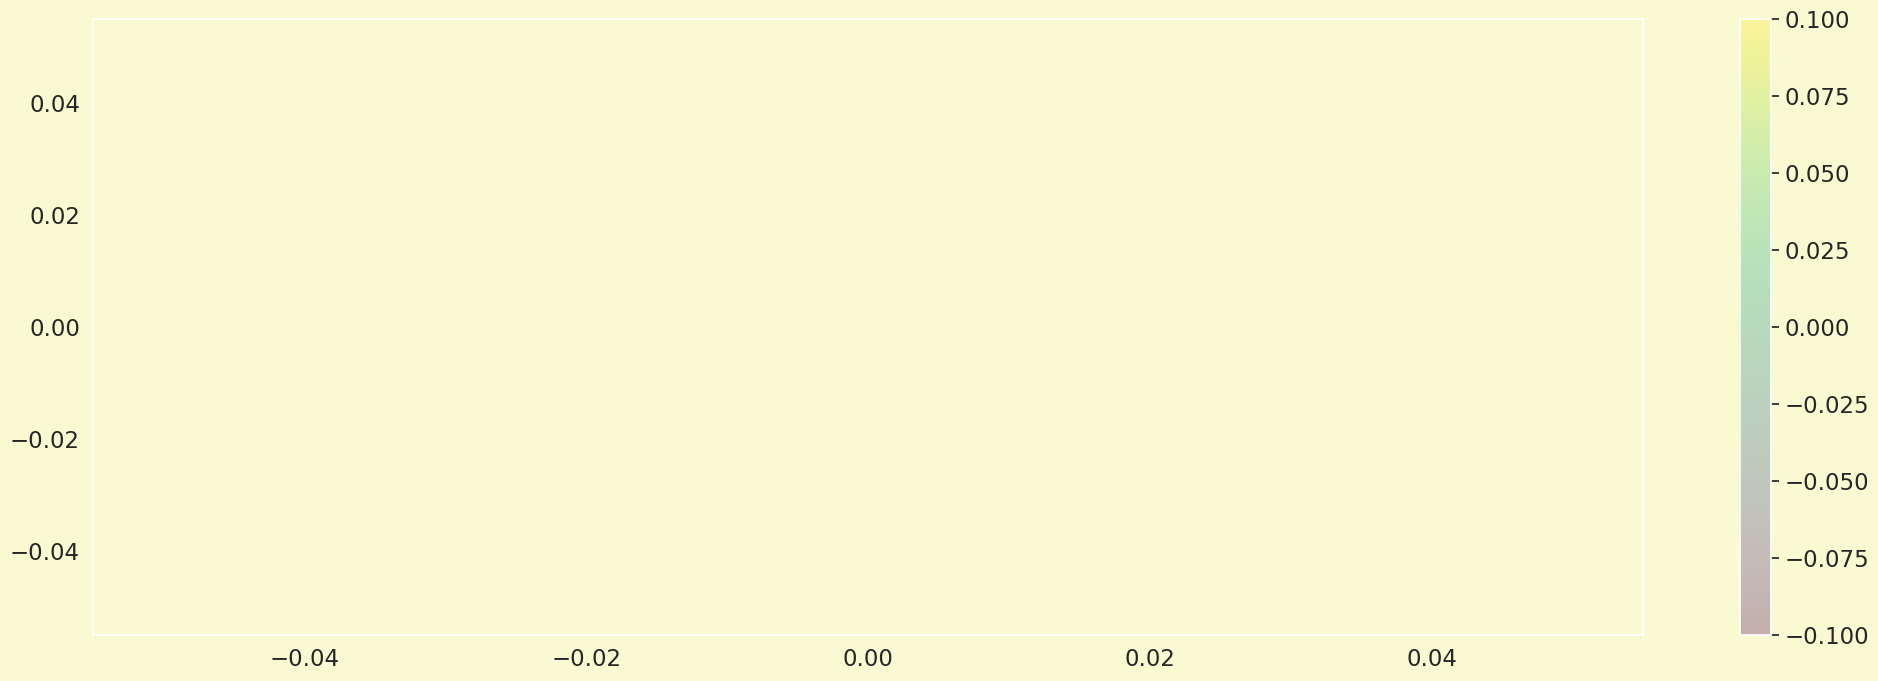

In [ ]:
x = df["Ratings"]
y = df["Cost Per Head"]
colors = df["Cost Per Head"]
sizes = df["Cost Per Head"]

plt.figure(figsize = (25, 8))
plt.ticklabel_format(style = 'plain')
plt.scatter(x, y, c = colors, s = sizes, alpha = 0.3, cmap = 'viridis')
plt.colorbar();

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">Low mean Cost Per Head & High mean Cost Per Head   </span>

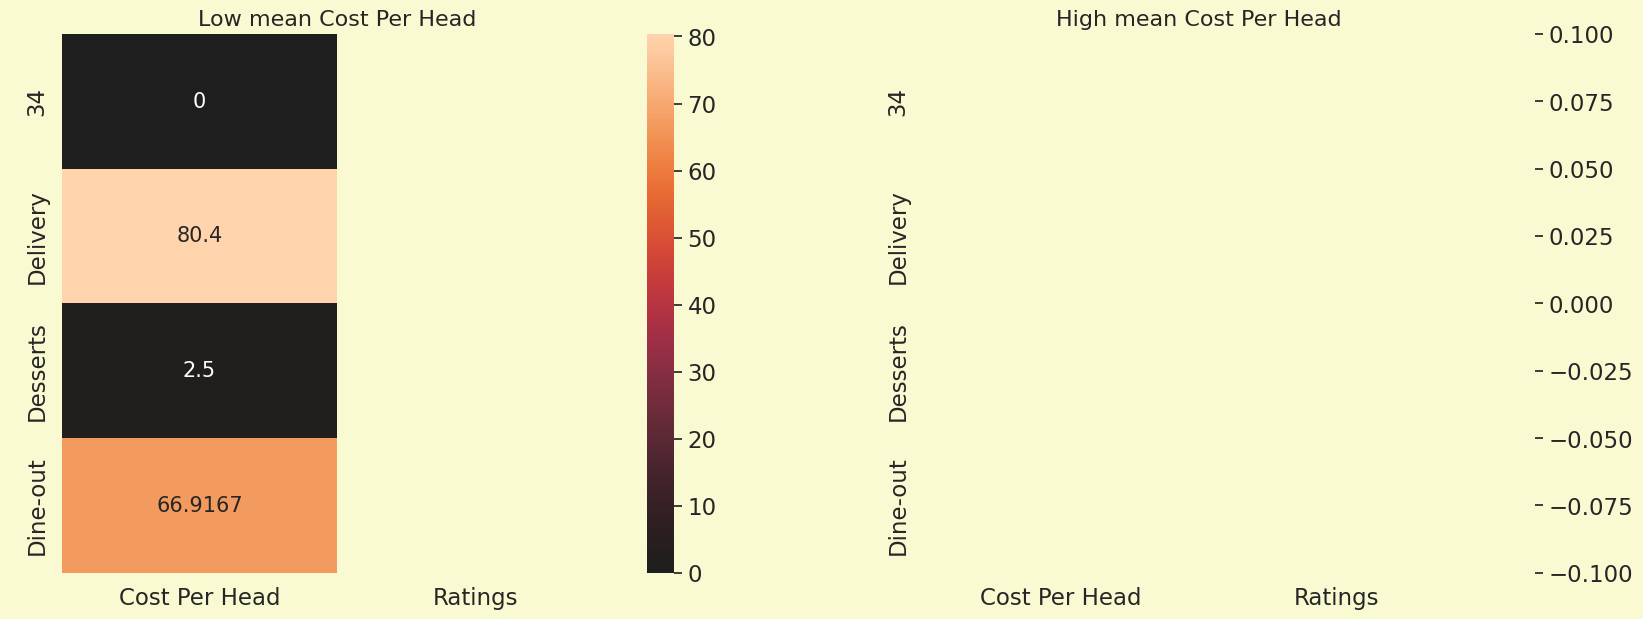

In [ ]:
category = df.groupby('Catagory')[['Cost Per Head', 'Ratings']].agg('mean')

low = category[category < 300]
high = category[category > 300]

fig = plt.figure(figsize=(20,7), dpi=100)
fig.subplots_adjust(wspace=0.25)
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
sns.heatmap(low, annot=True, fmt='.6g', center=0, ax=ax1)
sns.heatmap(high, annot=True, fmt='.6g', center=0, ax=ax2)
ax1.set_title('Low mean Cost Per Head', fontdict={'fontsize': 16})
ax2.set_title('High mean Cost Per Head', fontdict={'fontsize': 16})
plt.show()

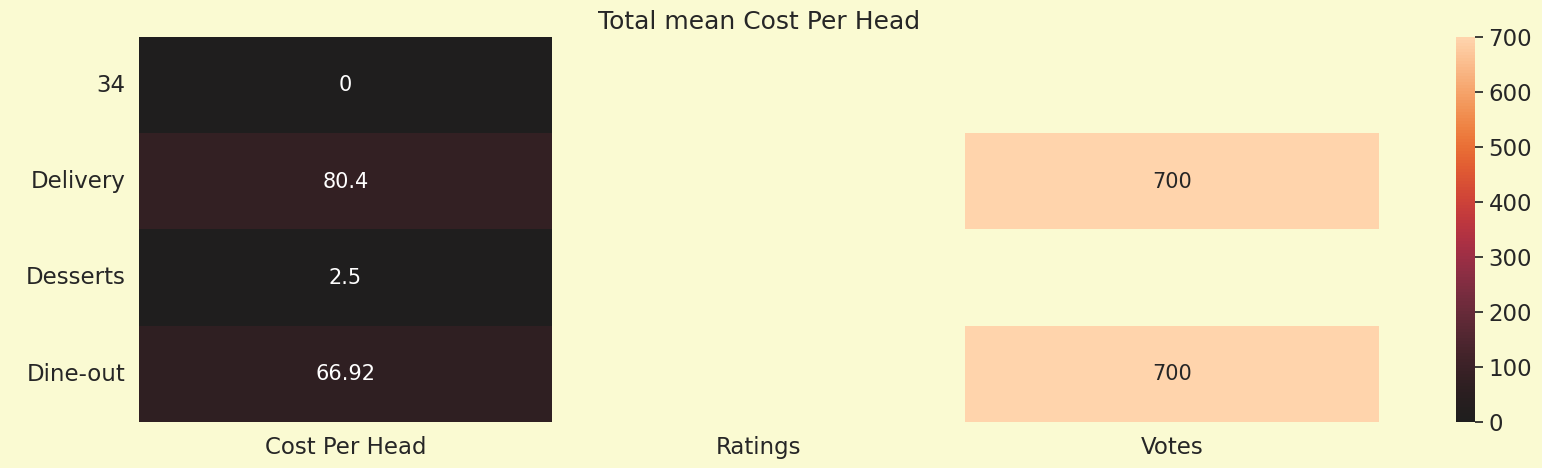

In [ ]:
category = df.groupby('Catagory')[['Cost Per Head', 'Ratings', 'Votes']].agg('mean')
plt.figure(figsize=(20,5), dpi=100)
sns.heatmap(category, annot=True, fmt=".4g", center=0)
plt.title('Total mean Cost Per Head')
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; "> Pairplot    </span>

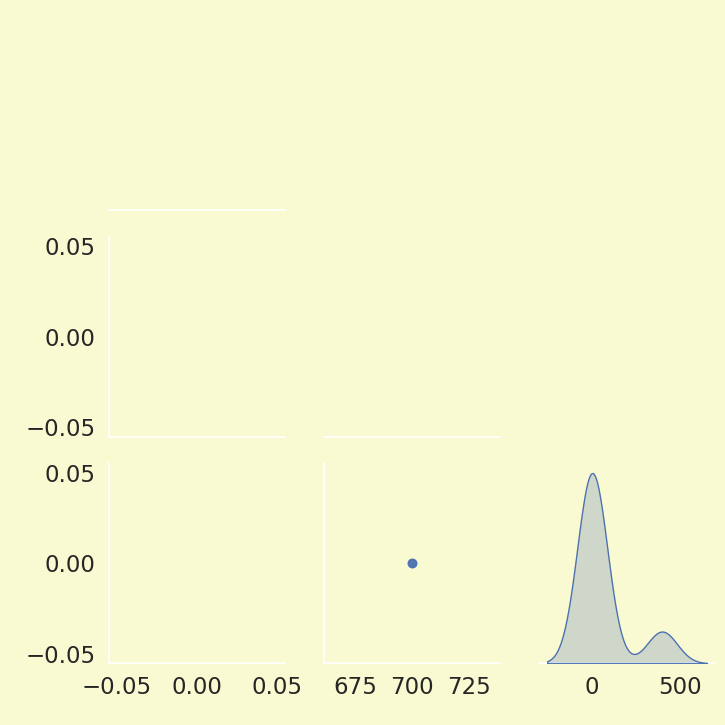

In [ ]:
sns.pairplot(df,kind="reg",diag_kind='kde',plot_kws={'line_kws':{'color':'red'}},corner=True)
plt.tight_layout()
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">  BarPlot of Catagory  </span>

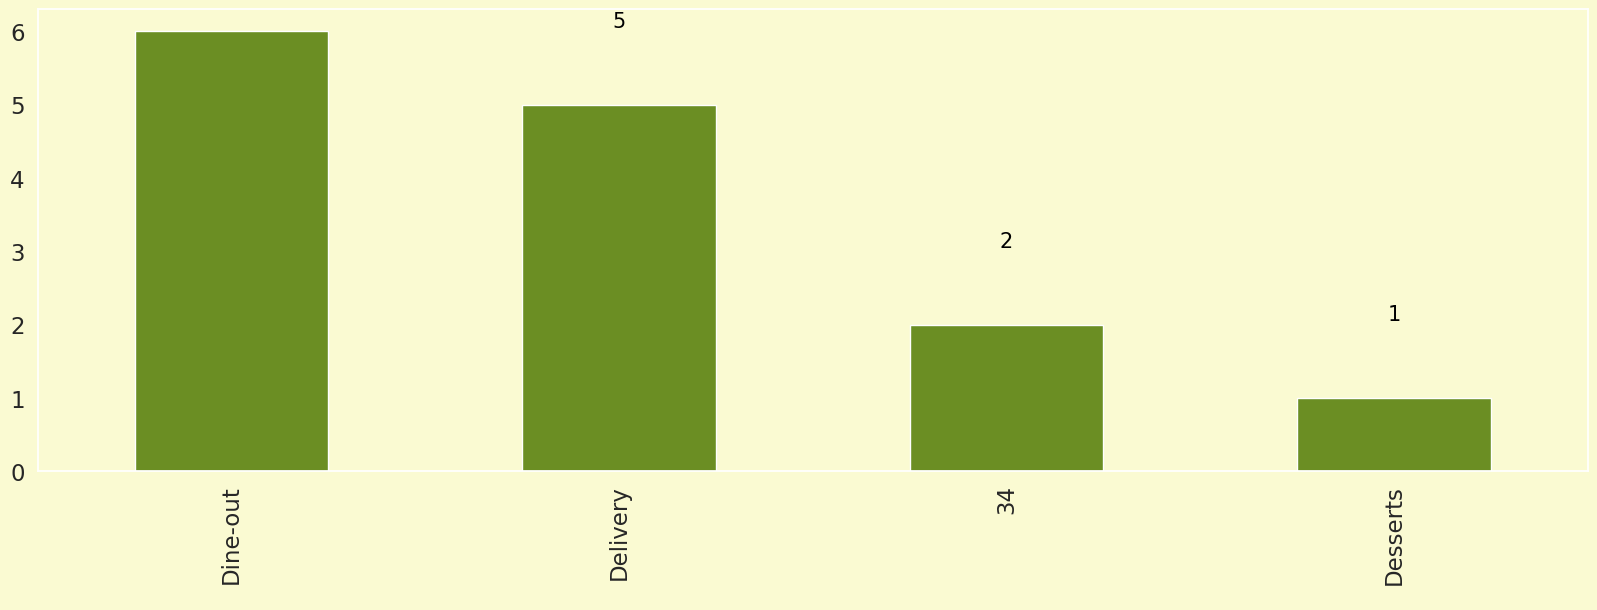

In [ ]:
plt.figure(figsize = (20, 6))
ax = df.Catagory.value_counts().plot(kind = 'bar', color = 'olivedrab')

for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + 0.25, p.get_height() + 1), ha = 'center', va = 'bottom', color = 'black')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">  BarPlot of Cuisines  </span>

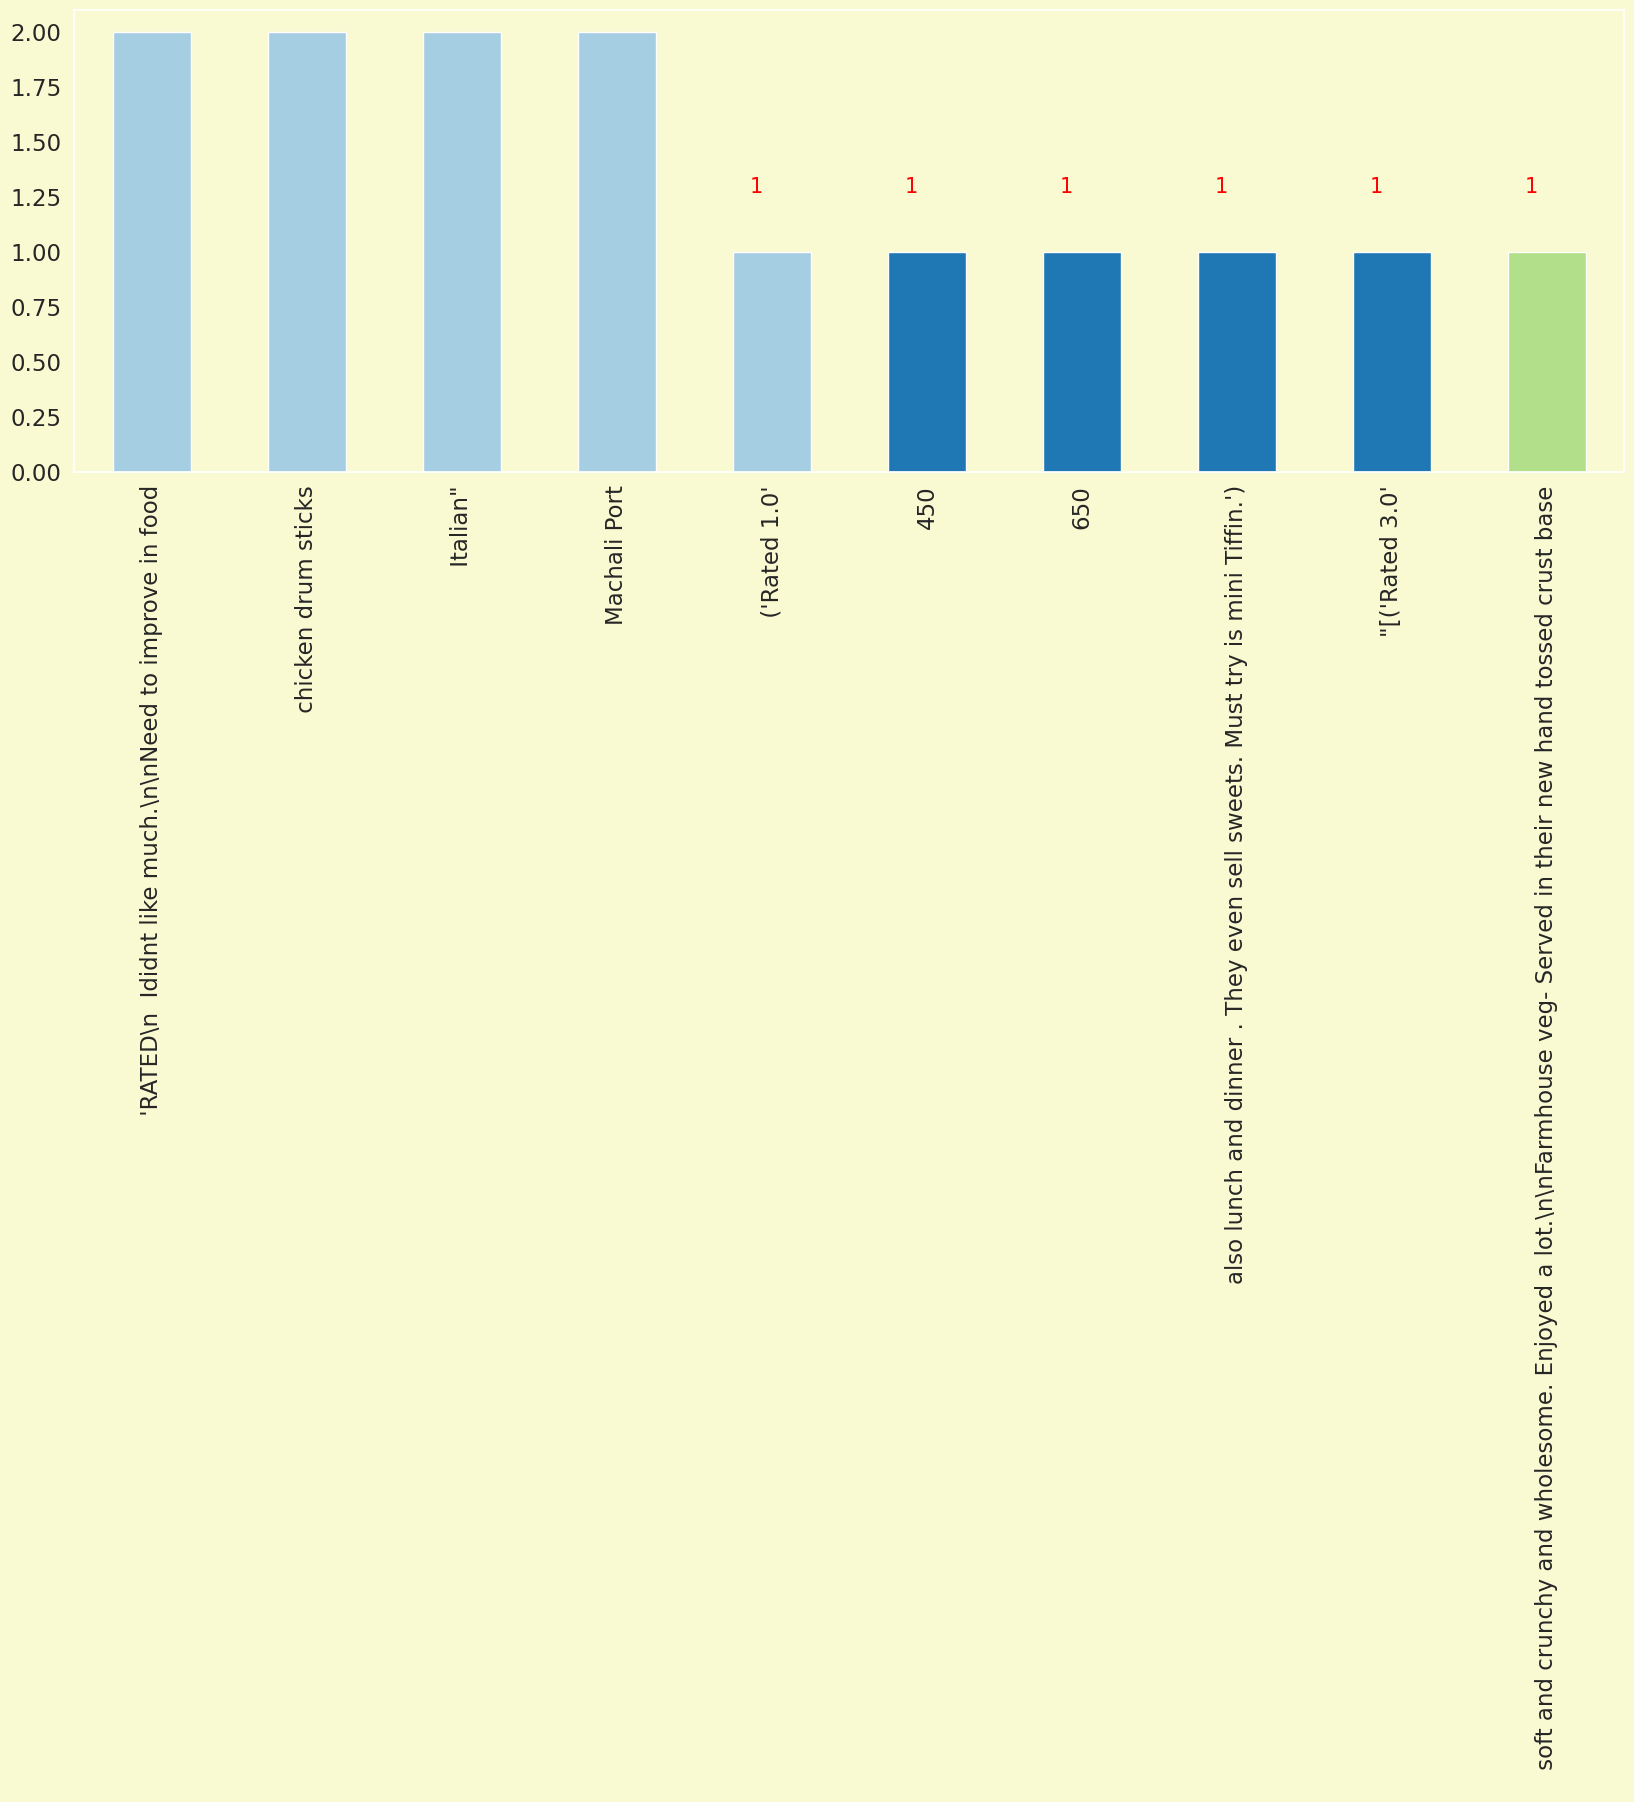

In [ ]:
plt.figure(figsize = (20, 6))
ax = df.Cuisines[0:50].value_counts().plot(kind = 'bar', color = plt.cm.Paired(np.linspace(0, 1, 50)))

for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + 0.15, p.get_height() + .25), ha = 'center', va = 'bottom', color = 'Red')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">  BarPlot of Cuisines Vs Cost Per Head  </span>

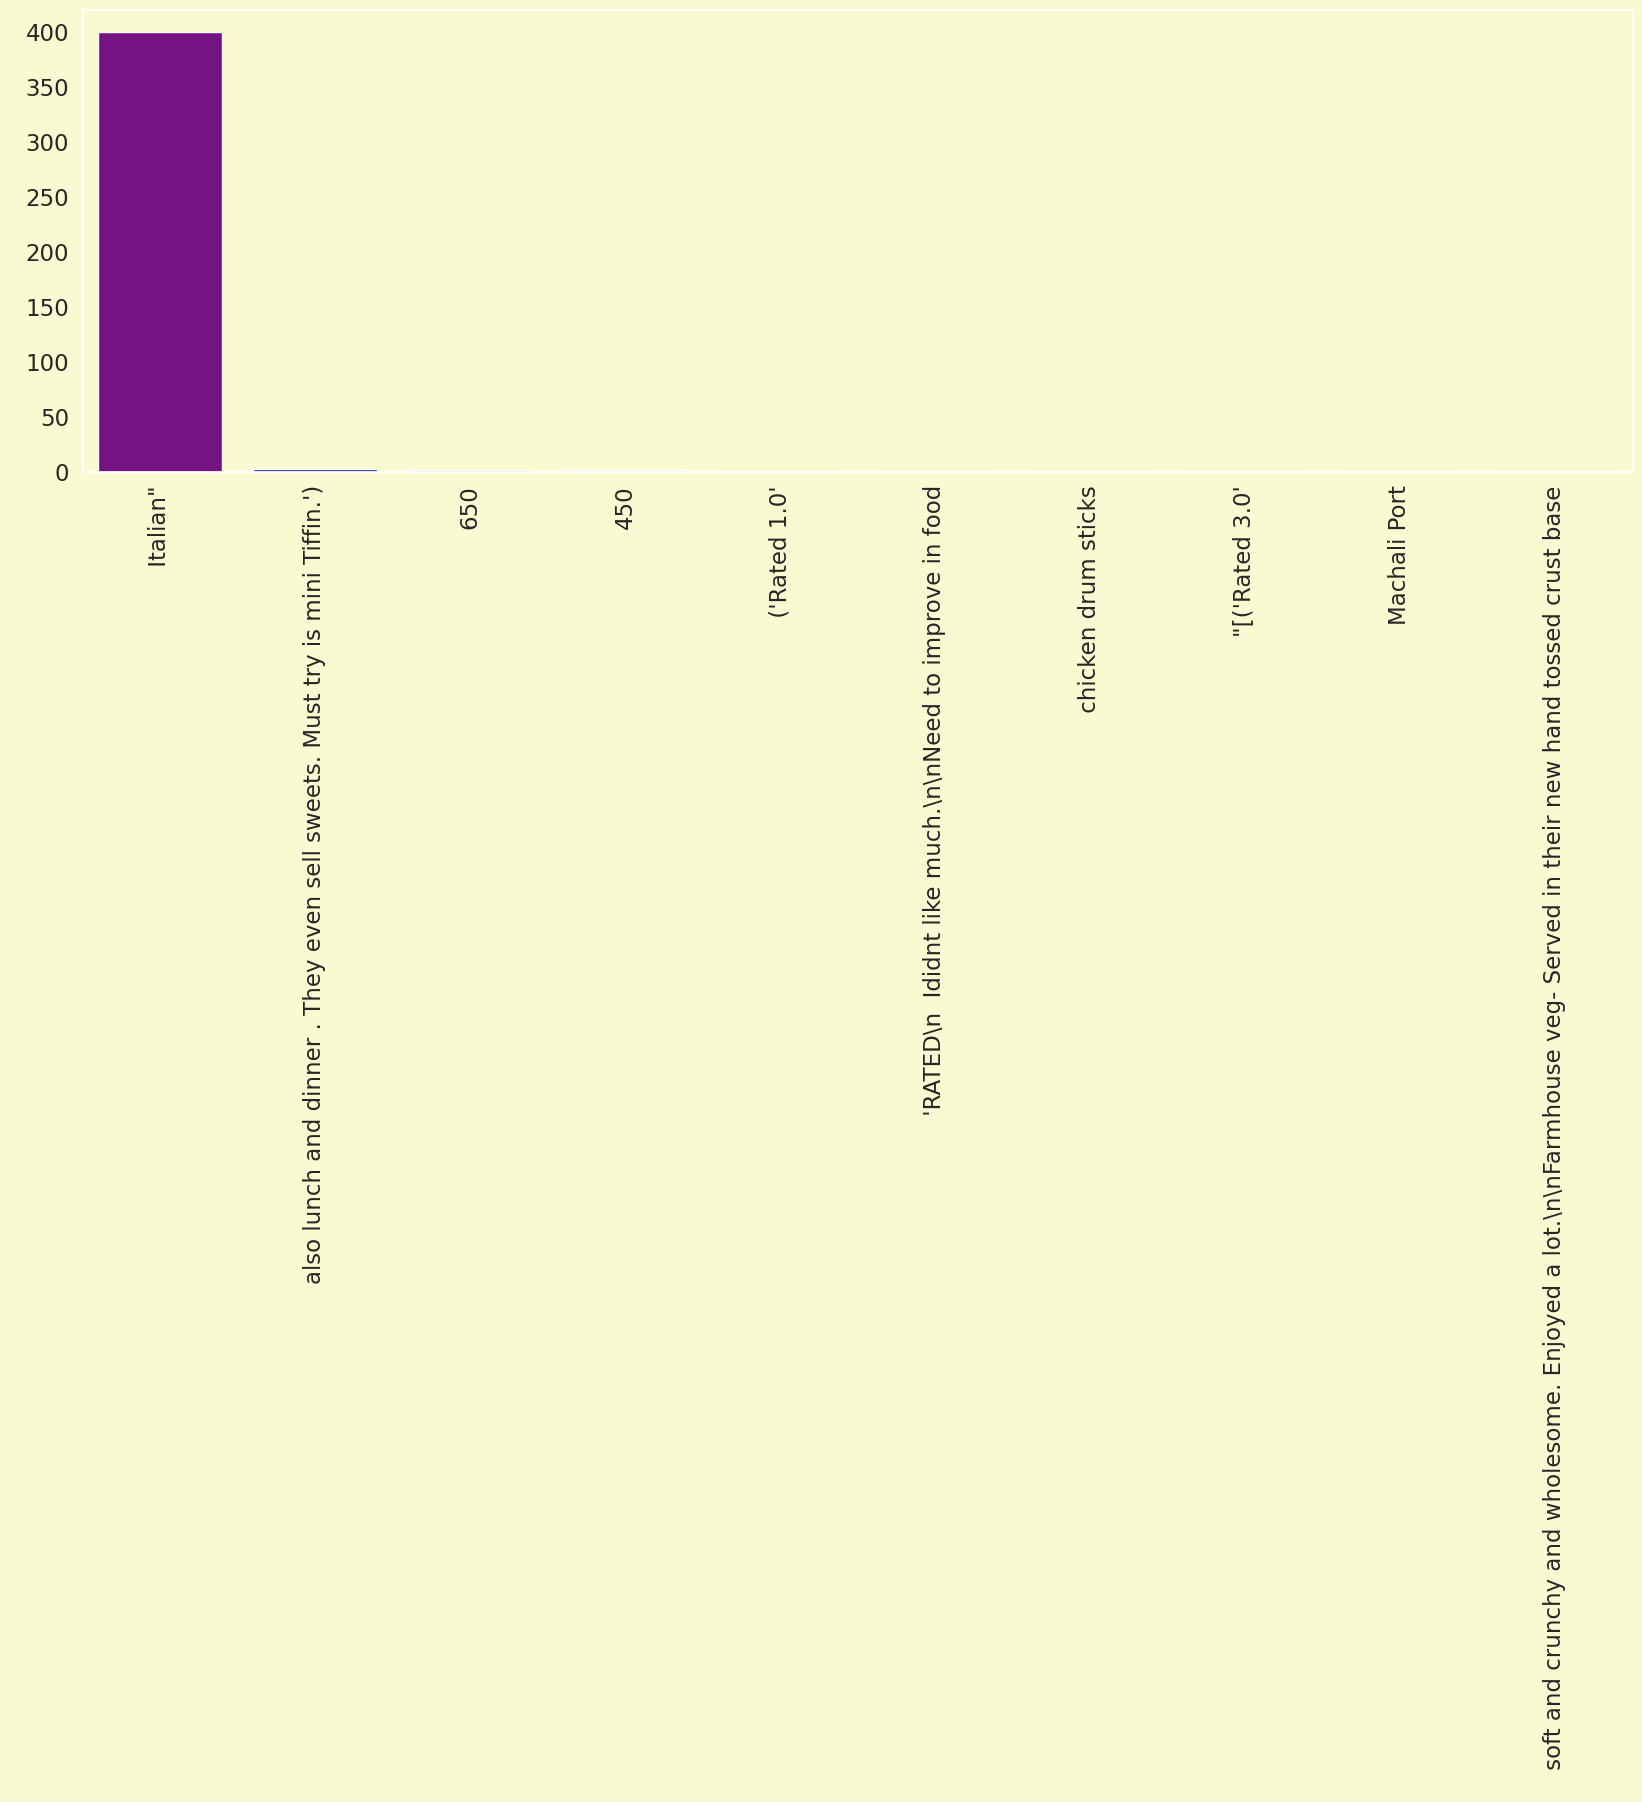

In [ ]:
plt.figure(figsize = (20, 6))
plt.xticks(rotation = 90)
plt.ticklabel_format(style = 'plain')
df.sort_values("Cost Per Head", axis = 0, ascending = False, inplace = True)
sns.barplot(x = df["Cuisines"][1:100],
            y = df["Cost Per Head"][1:100],
            palette = "nipy_spectral");

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">  BarPlot of Cost Per Head Vs Type Of Restaurant  </span>

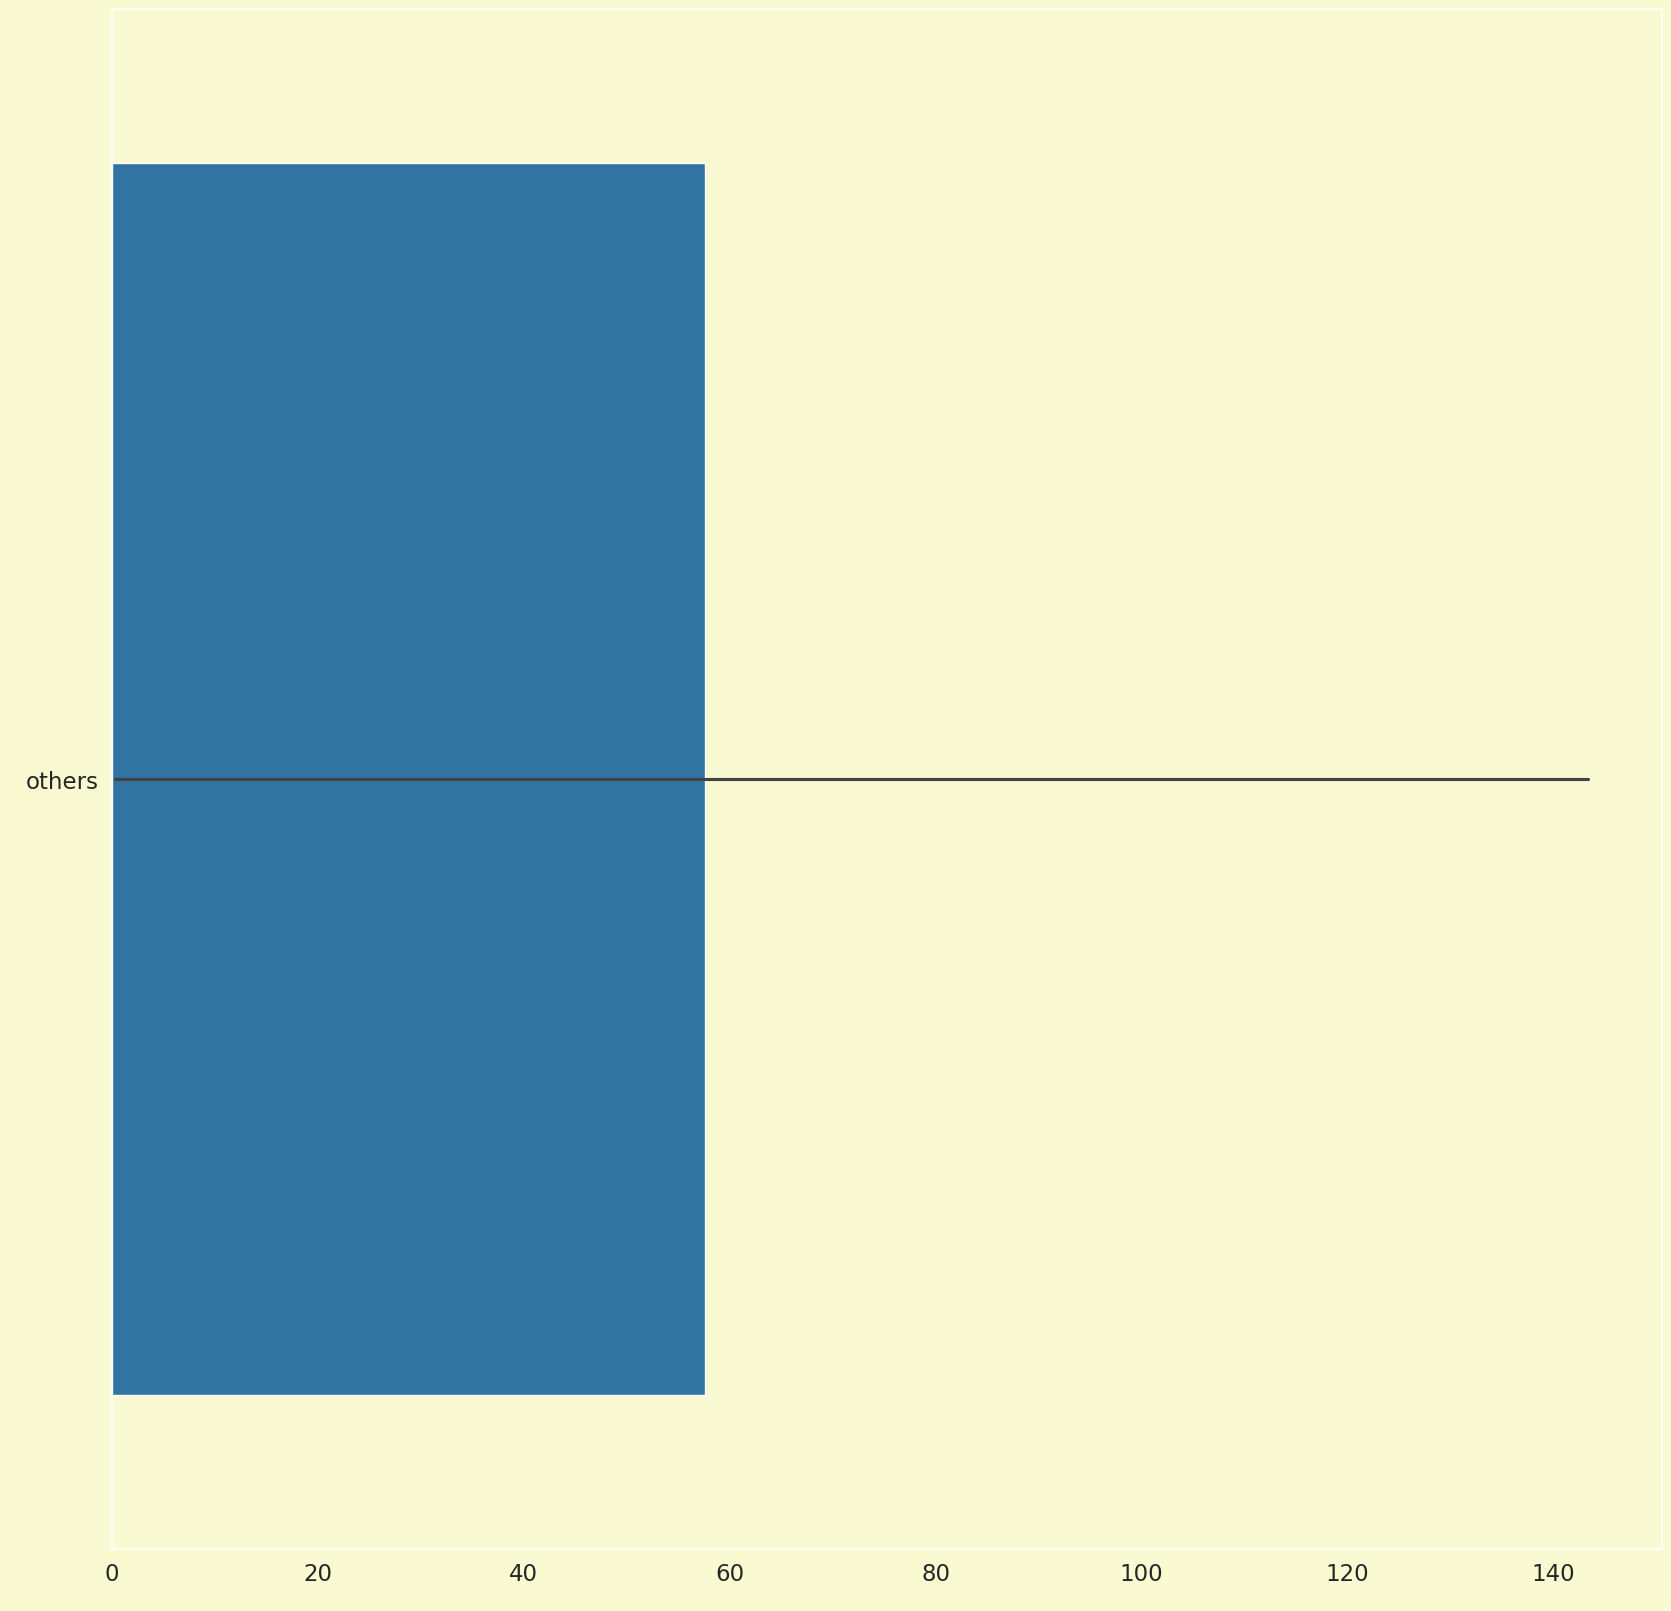

In [ ]:
plt.figure(figsize = (20, 20))
plt.ticklabel_format(style = 'plain')
sns.barplot(y = df["Type Of Restaurant"], x = df["Cost Per Head"], palette = "tab20");

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">  PieChat of Cuisines Liked in Bangalore  </span>

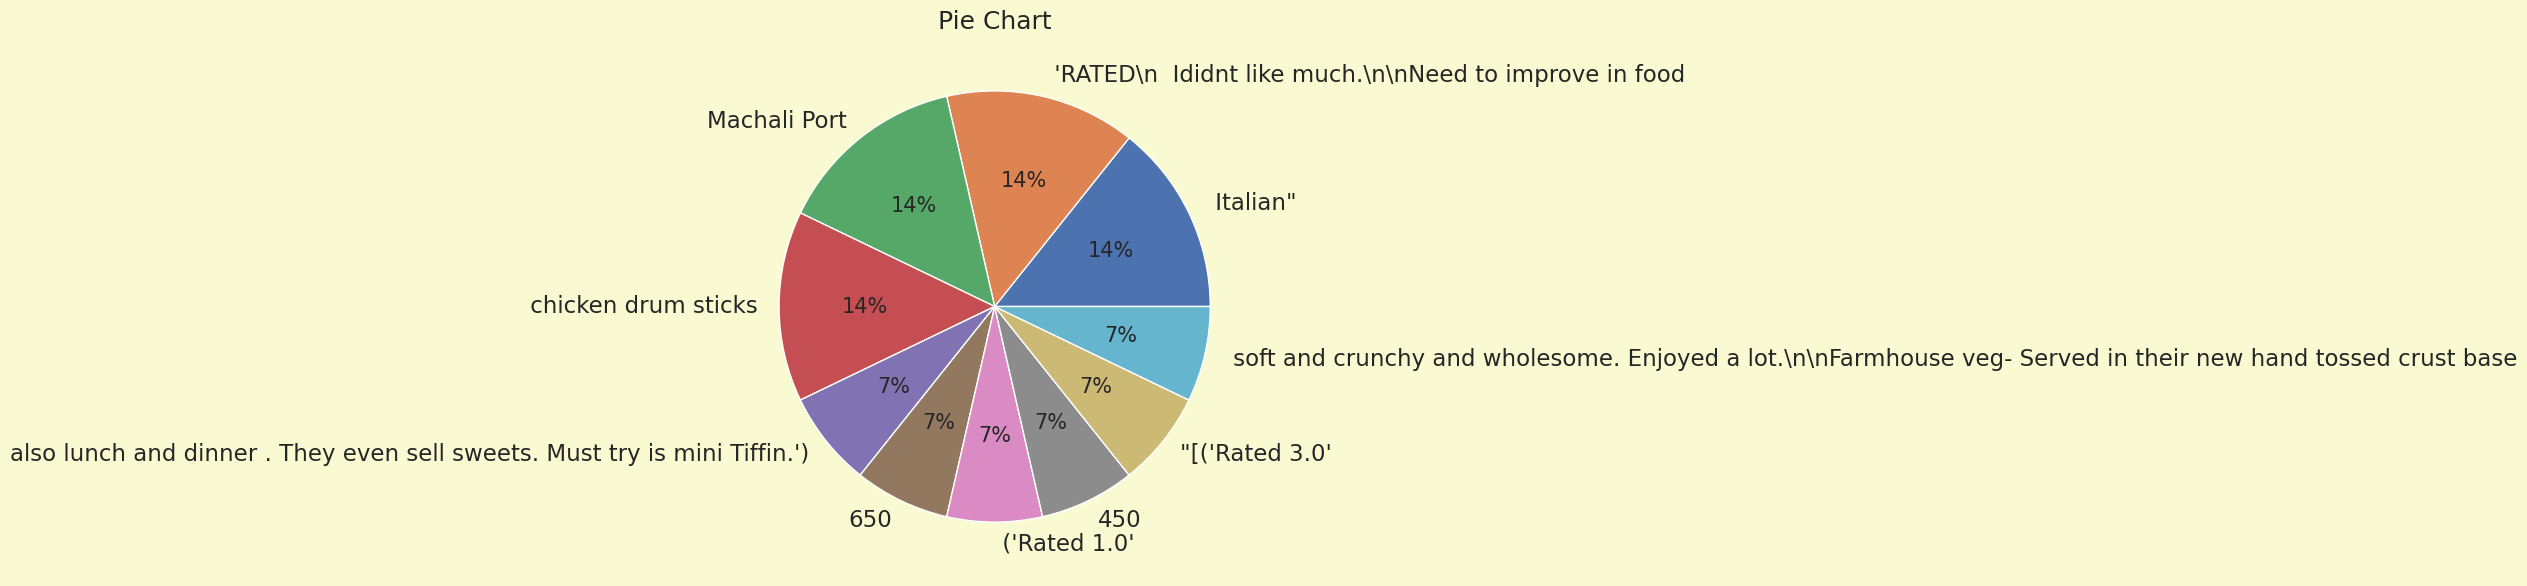

In [ ]:
df["Cuisines"].value_counts()[:20].plot.pie(figsize = (7, 7),
                                             autopct = '%1.0f%%')
plt.title("Pie Chart")
plt.xticks(rotation = 90)
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">   Barplot of Cost Per Head Vs Listed in City </span>

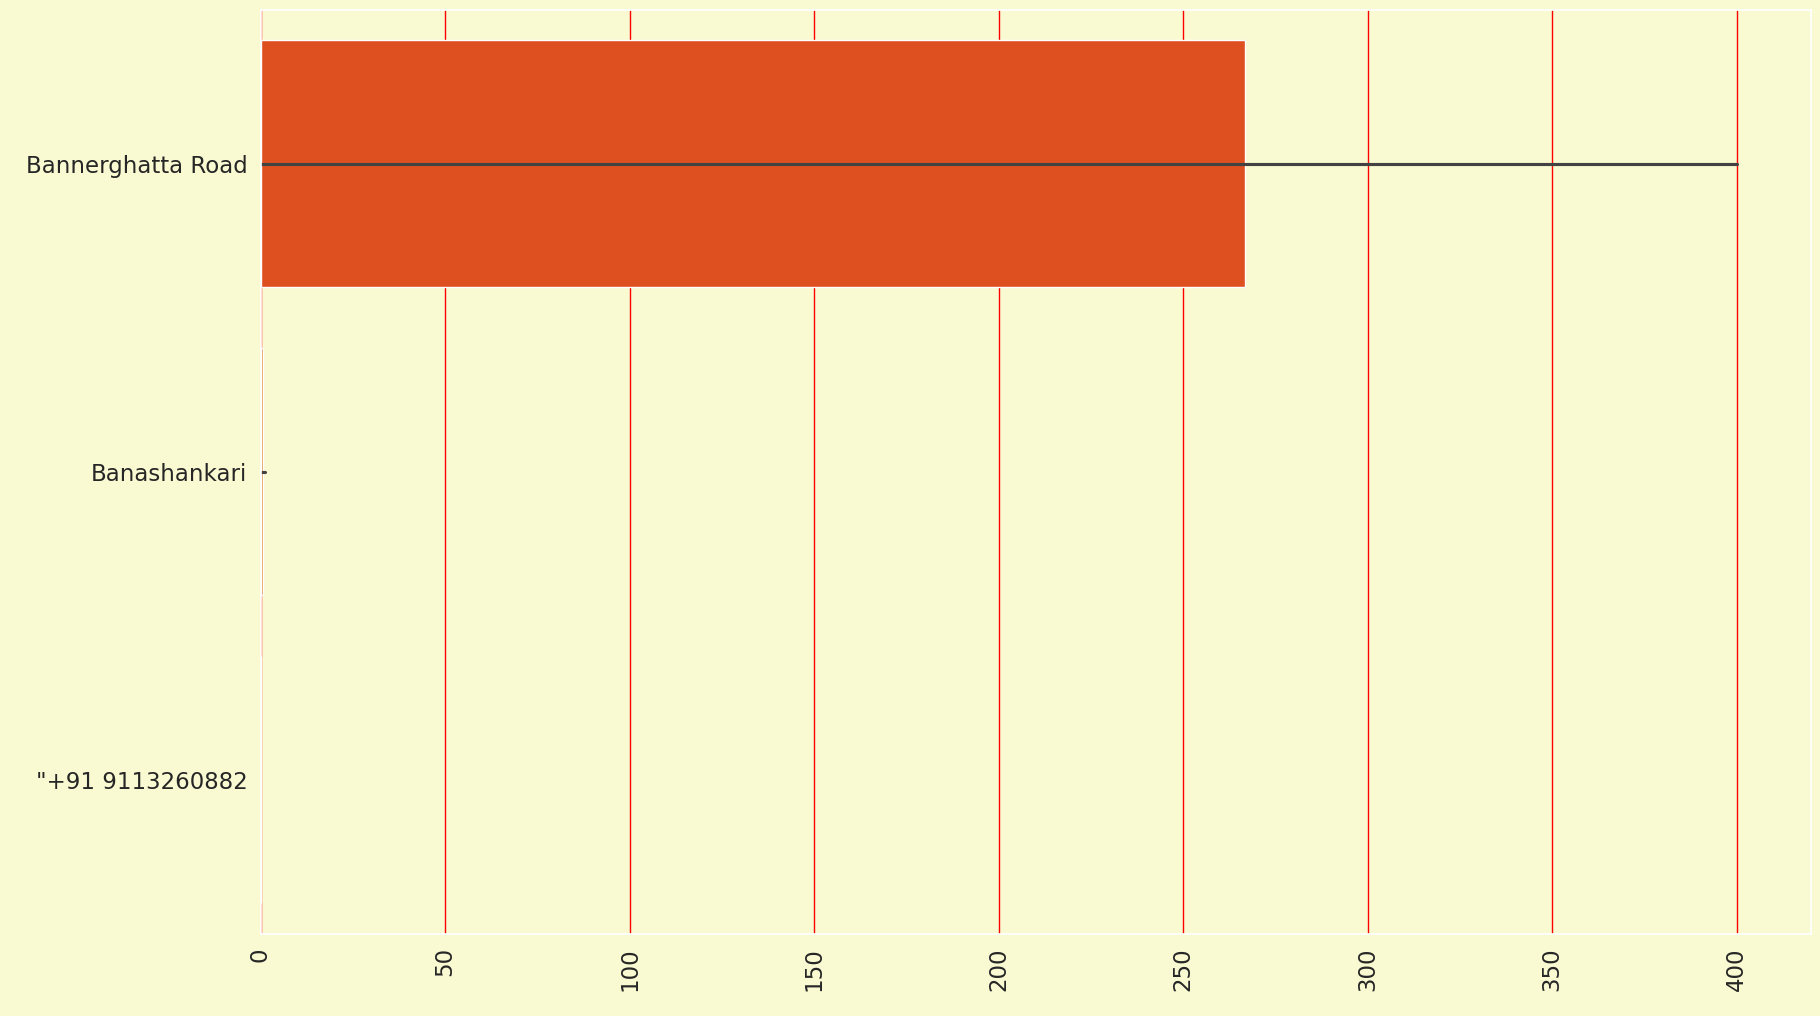

In [ ]:
plt.figure(figsize = (20, 12))
plt.grid()
plt.xticks(rotation = 90)
plt.ticklabel_format(style = 'plain')
df.sort_values("Listed in City", axis = 0,
                         ascending = False,
                         inplace = True)
sns.barplot(x = df["Cost Per Head"][:40000],
            y = df["Listed in City"],
            palette = "autumn");

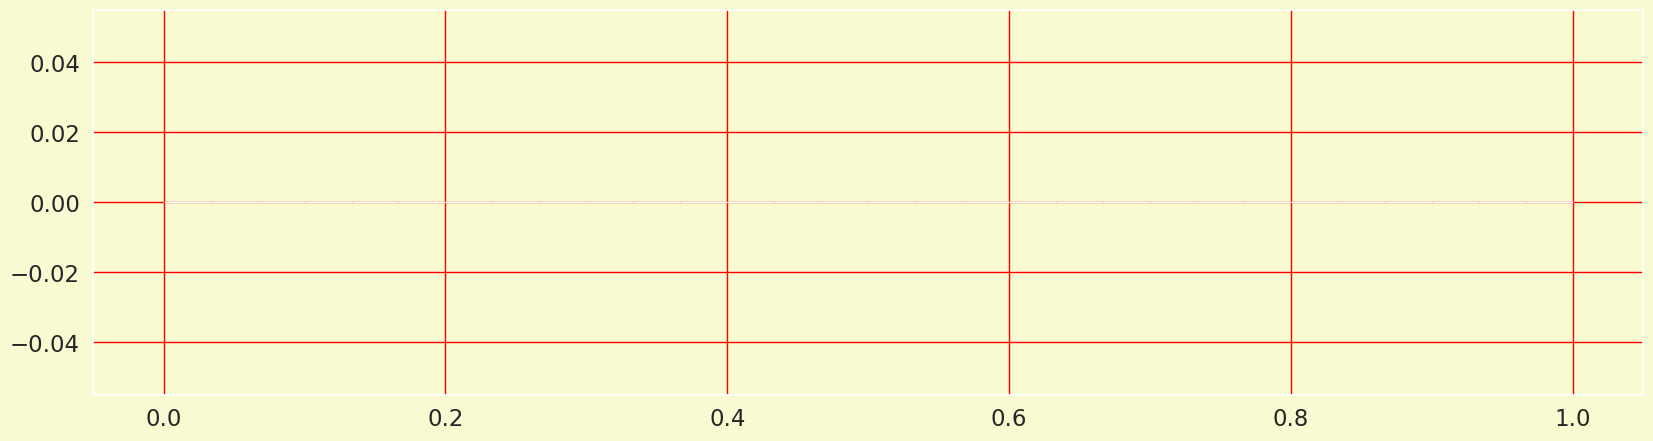

In [ ]:
n_bins = 30
plt.figure(figsize = (20, 5))
df["Ratings"].hist(bins = n_bins);

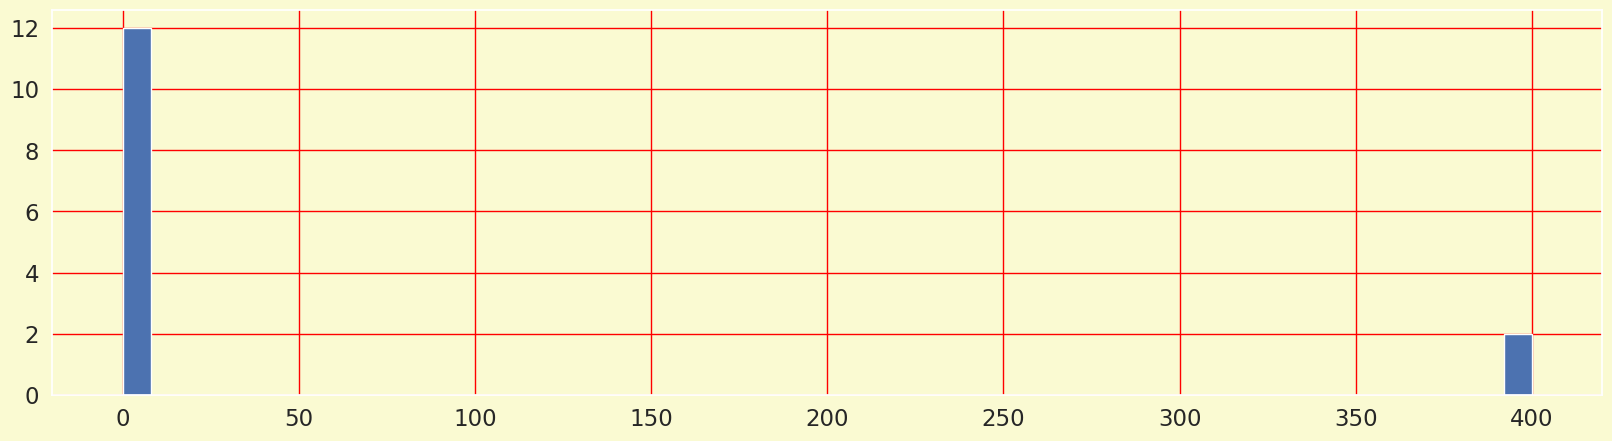

In [ ]:
n_bins = 50
plt.figure(figsize = (20, 5))
df["Cost Per Head"].hist(bins = n_bins);

In [ ]:
df['Ratings_Grade'].value_counts()

,count
Ratings_Grade,
F,14


<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">   PieChat of Ratings_Grade </span>

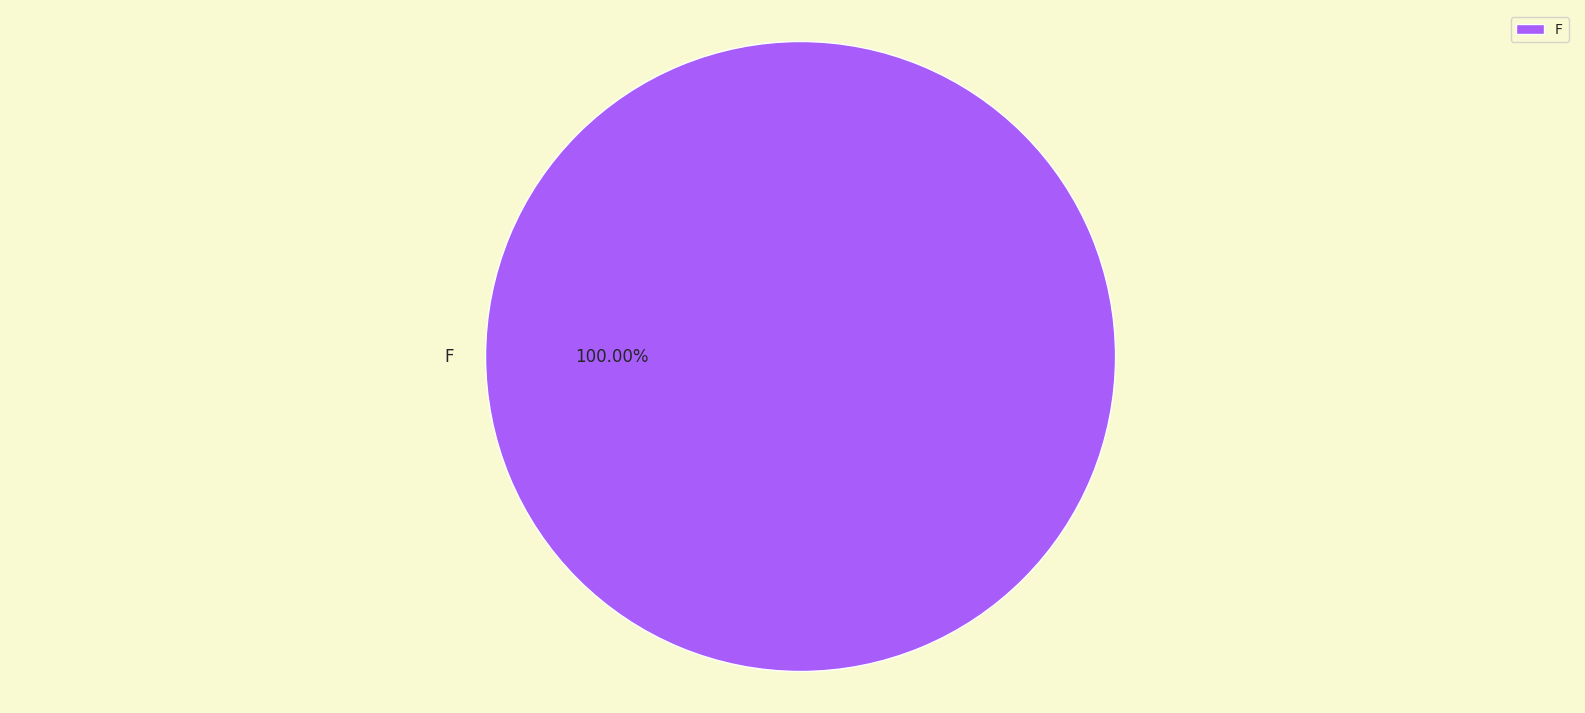

In [ ]:
# Configure or display Matplotlib plots
plt.figure(figsize = (20, 9))

counts = df["Ratings_Grade"].value_counts()
# Adjust the explode tuple to match the number of unique Ratings_Grade values
explode = (0, 0.1, 0.1, 0.1,0.3,0.4,0.7)[:len(counts)]
colors = ['#A85CF9', '#FF4949', '#BDF2D5', '#FF06B7', '#4B7BE5', '#FF5D5D', '#FAC213', '#37E2D5', '#6D8B74', '#E9D5CA', '#F77E21']

counts.plot(kind = 'pie', fontsize = 12, colors = colors, explode = explode, autopct = '%1.2f%%')
plt.axis('equal')
plt.legend(labels = counts.index, loc = "best")
plt.show()

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">   Barplot of Location </span>

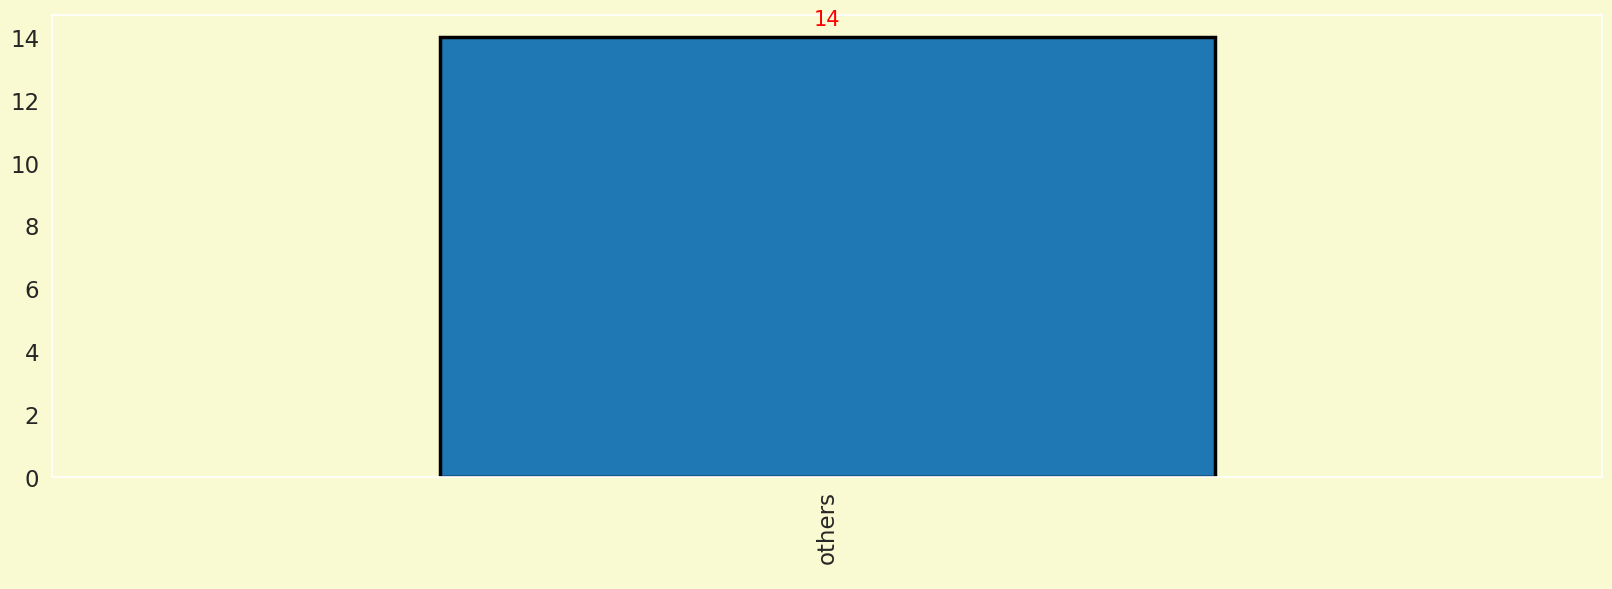

In [ ]:
# Configure or display Matplotlib plots
plt.figure(figsize = (20, 6))
col_map = plt.get_cmap('tab20')
ax = df["Location"][:200].value_counts().plot(kind = 'bar',color = col_map.colors,rot = 0, edgecolor = 'Black',linewidth = 2.5)
# Configure or display Matplotlib plots
plt.xticks(rotation=90)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + 0.25, p.get_height() + .25), ha = 'center', va = 'bottom', color = 'Red')

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Comic Sans MS; font-size:28px; color:#FBFAFC; ">   Barplot of Restaurant Name Vs Cost Per Head </span>

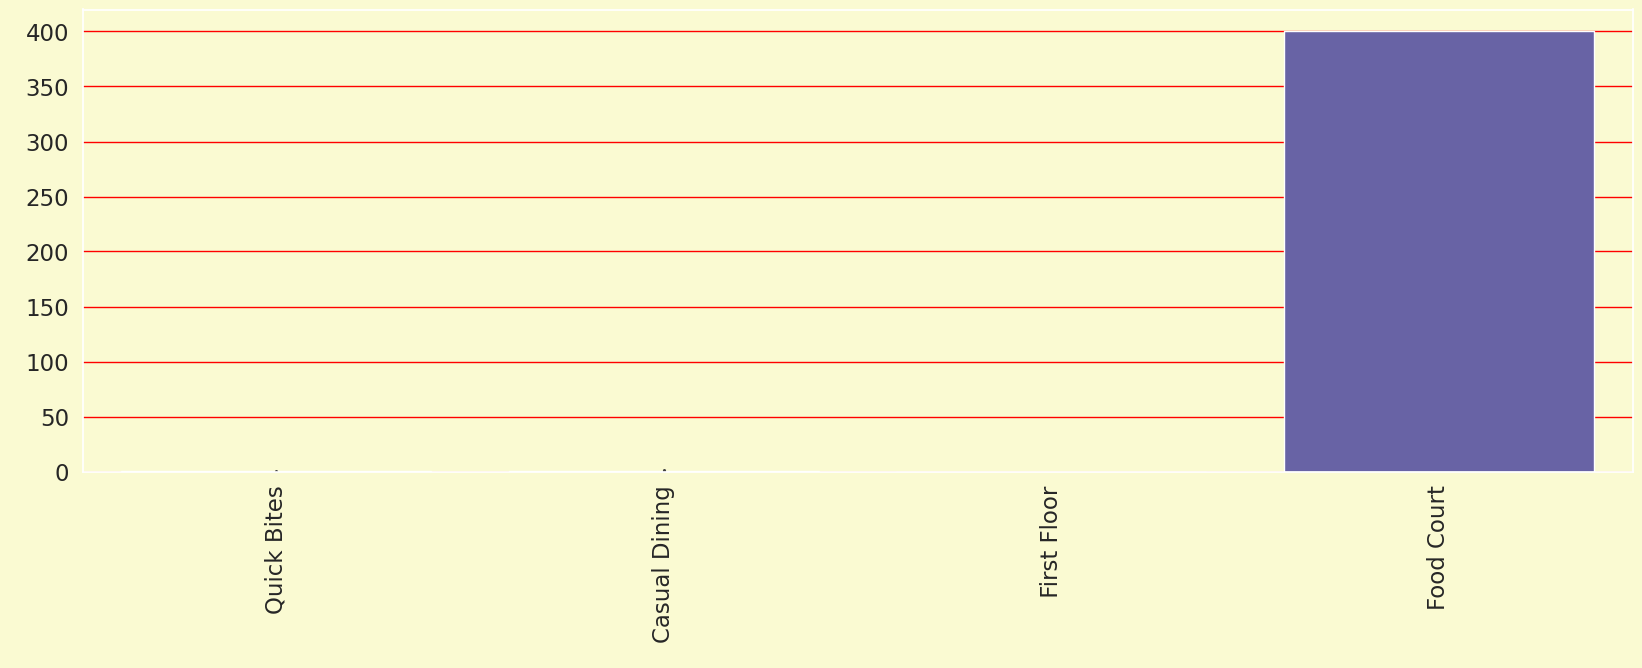

In [ ]:
# Bar Plot for Restaurant Name Vs Top 100 Lowest Cost Per Head
plt.figure(figsize = (20, 6))
plt.grid()
plt.xticks(rotation = 90)
plt.ticklabel_format(style = 'plain')
df.sort_values("Cost Per Head", axis = 0, ascending = True, inplace = True)
sns.barplot(x = df["Restaurant Name"][:70], y = df["Cost Per Head"], palette = "twilight_shifted_r");

<div style="color:white;background-color:#e90045;padding:3%;border-radius:150px 150px;font-size:2em;text-align:center"> <font color="White" size=+5 face="Lucida Calligraphy"><div style="align:center: justify">Work in Progress</font></div>